# Proyecto de Regresión: Metro Interstate Traffic Volume

## 3. Desarrollo del proyecto conforme a CRISP-DM

Este proyecto se desarrolla siguiendo la metodología CRISP-DM, aplicada a un problema de regresión. El objetivo general es construir, evaluar y desplegar un modelo de aprendizaje automático capaz de predecir el volumen horario de tráfico vehicular a partir de variables climáticas y temporales.

## 3.1 Comprensión del negocio

### Introducción al problema

El dataset utilizado se denomina **Metro Interstate Traffic Volume**. Contiene registros horarios del volumen de tráfico vehicular en la carretera interestatal I-94, ubicada en la zona de Minneapolis y St. Paul, en Estados Unidos. Además de la variable objetivo, el dataset incluye información sobre condiciones meteorológicas, días festivos y fecha/hora del registro.

El fenómeno analizado corresponde a la variación del flujo vehicular según el tiempo y las condiciones ambientales. Este análisis es útil porque permite estudiar patrones de movilidad, horarios de mayor congestión y factores que pueden influir en la cantidad de vehículos que circulan por una carretera.

### Objetivo de la predicción

La variable dependiente es **traffic_volume**, que representa el volumen de tráfico vehicular registrado por hora. Su unidad se interpreta como vehículos por hora.

Aunque la variable se almacena como un valor entero, se trabaja como una variable cuantitativa para una tarea de regresión, ya que representa una magnitud numérica con muchos valores posibles. El objetivo es estimar el volumen de tráfico a partir de variables meteorológicas y temporales.

### Aplicación del modelo

El modelo podría utilizarse como apoyo para la gestión del tráfico, planeación vial o sistemas de movilidad. Sus predicciones podrían ayudar a anticipar congestionamientos, planear operativos, recomendar rutas alternativas o seleccionar mejores horarios para transporte y logística.

Una predicción incorrecta podría causar decisiones inadecuadas, como subestimar una congestión o asignar recursos viales de manera innecesaria. Por ello, el modelo debe considerarse una herramienta de apoyo y no una sustitución total del criterio humano o de otros sistemas de monitoreo en tiempo real.

## 3.2 Comprensión de los datos

En esta etapa se analiza el dataset antes de realizar transformaciones de preparación o modelado. El objetivo es conocer su estructura, identificar los tipos de variables, revisar la calidad de los datos y observar patrones iniciales relacionados con la variable dependiente `traffic_volume`.

In [128]:
# =========================================================
# 3.2 Comprensión de los datos
# Carga remota del dataset
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

# URL Raw del dataset en GitHub
url = "https://raw.githubusercontent.com/Lara-Sis/metro-traffic-volume-regression/refs/heads/main/data/Metro_Interstate_Traffic_Volume.csv"

# Carga del dataset
dataset = pd.read_csv(url)

# Vista inicial
dataset.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.280,0.000,0.000,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.360,0.000,0.000,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.580,0.000,0.000,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.130,0.000,0.000,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.140,0.000,0.000,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [129]:
# =========================================================
# Dimensiones originales del dataset
# =========================================================

print("Número de registros y columnas:")
print(dataset.shape)

print(f"Registros originales: {dataset.shape[0]}")
print(f"Columnas originales: {dataset.shape[1]}")
print(f"Variables independientes originales: {dataset.shape[1] - 1}")
print("Variable dependiente: traffic_volume")

Número de registros y columnas:
(48204, 9)
Registros originales: 48204
Columnas originales: 9
Variables independientes originales: 8
Variable dependiente: traffic_volume


El dataset contiene 48,204 registros y 9 columnas. De estas columnas, 8 corresponden a variables independientes y una corresponde a la variable dependiente `traffic_volume`.

Esto permite cumplir el requisito del proyecto, ya que el dataset cuenta con más de 600 registros útiles y al menos 8 variables predictoras originales.

In [130]:
# =========================================================
# Información general del dataset
# =========================================================

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


In [131]:
# =========================================================
# Tabla de descripción de atributos originales
# =========================================================

descripcion_atributos = {
    "holiday": "Día festivo registrado. Si no hay festividad, aparece como valor faltante en el CSV.",
    "temp": "Temperatura promedio registrada en Kelvin.",
    "rain_1h": "Cantidad de lluvia registrada en la última hora, en milímetros.",
    "snow_1h": "Cantidad de nieve registrada en la última hora, en milímetros.",
    "clouds_all": "Porcentaje de nubosidad.",
    "weather_main": "Descripción corta del clima actual.",
    "weather_description": "Descripción detallada del clima actual.",
    "date_time": "Fecha y hora del registro.",
    "traffic_volume": "Volumen horario de tráfico vehicular. Variable dependiente."
}

tipo_atributo = {
    "holiday": "Nominal",
    "temp": "Continuo",
    "rain_1h": "Continuo",
    "snow_1h": "Continuo",
    "clouds_all": "Continuo",
    "weather_main": "Nominal",
    "weather_description": "Nominal",
    "date_time": "Discreto temporal",
    "traffic_volume": "Continuo para regresión"
}

tabla_atributos = pd.DataFrame({
    "Atributo": dataset.columns,
    "Descripción": [descripcion_atributos[col] for col in dataset.columns],
    "Tipo de atributo": [tipo_atributo[col] for col in dataset.columns],
    "Tipo de dato en Python": [str(dataset[col].dtype) for col in dataset.columns],
    "Nulos": dataset.isnull().sum().values,
    "Porcentaje de nulos": (dataset.isnull().mean().values * 100).round(2)
})

tabla_atributos

,Atributo,Descripción,Tipo de atributo,Tipo de dato en Python,Nulos,Porcentaje de nulos
0,holiday,"Día festivo registrado. Si no hay festividad, ...",Nominal,str,48143,99.870
1,temp,Temperatura promedio registrada en Kelvin.,Continuo,float64,0,0.000
2,rain_1h,Cantidad de lluvia registrada en la última hor...,Continuo,float64,0,0.000
3,snow_1h,Cantidad de nieve registrada en la última hora...,Continuo,float64,0,0.000
4,clouds_all,Porcentaje de nubosidad.,Continuo,int64,0,0.000
5,weather_main,Descripción corta del clima actual.,Nominal,str,0,0.000
6,weather_description,Descripción detallada del clima actual.,Nominal,str,0,0.000
7,date_time,Fecha y hora del registro.,Discreto temporal,str,0,0.000
8,traffic_volume,Volumen horario de tráfico vehicular. Variable...,Continuo para regresión,int64,0,0.000


La tabla de atributos permite identificar el tipo de variable, el tipo de dato en Python y la presencia de valores nulos. Se observa que la columna `holiday` presenta una gran cantidad de valores faltantes aparentes. Sin embargo, estos valores representan registros donde no existe un día festivo asociado, por lo que posteriormente se tratarán como una categoría llamada `None` o `Sin festivo`.

Las variables `weather_main` y `weather_description` son categóricas nominales, por lo que deberán convertirse a valores numéricos antes del modelado. La columna `date_time` es temporal y no debe utilizarse directamente como texto; más adelante se extraerán variables como hora, día de la semana, mes y fin de semana.

### Calidad de los datos

En esta parte se revisa la presencia de duplicados, valores nulos, posibles valores inválidos, columnas constantes, baja variabilidad, identificadores sin utilidad predictiva y posibles casos de fuga de datos.

In [132]:
# =========================================================
# Registros duplicados y valores nulos
# =========================================================

duplicados = dataset.duplicated().sum()
print(f"Registros duplicados exactos: {duplicados}")

nulos = pd.DataFrame({
    "Nulos": dataset.isnull().sum(),
    "Porcentaje": (dataset.isnull().mean() * 100).round(2)
})

nulos

Registros duplicados exactos: 17


,Nulos,Porcentaje
holiday,48143,99.870
temp,0,0.000
rain_1h,0,0.000
snow_1h,0,0.000
clouds_all,0,0.000
weather_main,0,0.000
weather_description,0,0.000
date_time,0,0.000
traffic_volume,0,0.000


In [133]:
# =========================================================
# Valores únicos por columna
# =========================================================

valores_unicos = pd.DataFrame({
    "Valores únicos": dataset.nunique(dropna=False),
    "Porcentaje de valores únicos": (dataset.nunique(dropna=False) / len(dataset) * 100).round(2)
})

valores_unicos

,Valores únicos,Porcentaje de valores únicos
holiday,12,0.020
temp,5843,12.120
rain_1h,372,0.770
snow_1h,12,0.020
clouds_all,60,0.120
weather_main,11,0.020
weather_description,38,0.080
date_time,40575,84.170
traffic_volume,6704,13.910


In [134]:
# =========================================================
# Columnas constantes o con poca variabilidad
# =========================================================

columnas_constantes = [col for col in dataset.columns if dataset[col].nunique(dropna=False) == 1]
columnas_baja_variabilidad = [col for col in dataset.columns if dataset[col].nunique(dropna=False) <= 2]

print("Columnas constantes:")
print(columnas_constantes)

print("\nColumnas con poca variabilidad:")
print(columnas_baja_variabilidad)

Columnas constantes:
[]

Columnas con poca variabilidad:
[]


In [135]:
# =========================================================
# Revisión de posibles valores inválidos o atípicos
# =========================================================

print("Temperatura mínima:", dataset["temp"].min())
print("Temperatura máxima:", dataset["temp"].max())
print("Registros con temp = 0 Kelvin:", (dataset["temp"] == 0).sum())

print("\nLluvia mínima:", dataset["rain_1h"].min())
print("Lluvia máxima:", dataset["rain_1h"].max())
print("Registros con rain_1h > 100 mm:", (dataset["rain_1h"] > 100).sum())

print("\nNieve mínima:", dataset["snow_1h"].min())
print("Nieve máxima:", dataset["snow_1h"].max())

print("\nTráfico mínimo:", dataset["traffic_volume"].min())
print("Tráfico máximo:", dataset["traffic_volume"].max())
print("Registros con traffic_volume = 0:", (dataset["traffic_volume"] == 0).sum())

Temperatura mínima: 0.0
Temperatura máxima: 310.07
Registros con temp = 0 Kelvin: 10

Lluvia mínima: 0.0
Lluvia máxima: 9831.3
Registros con rain_1h > 100 mm: 1

Nieve mínima: 0.0
Nieve máxima: 0.51

Tráfico mínimo: 0
Tráfico máximo: 7280
Registros con traffic_volume = 0: 2


In [136]:
# =========================================================
# Revisión de fecha/hora
# =========================================================

print("Cantidad de valores únicos en date_time:")
print(dataset["date_time"].nunique())

print("\nRegistros con date_time repetido:")
print(dataset["date_time"].duplicated().sum())

dataset["date_time"].head()

Cantidad de valores únicos en date_time:
40575

Registros con date_time repetido:
7629


0    2012-10-02 09:00:00
1    2012-10-02 10:00:00
2    2012-10-02 11:00:00
3    2012-10-02 12:00:00
4    2012-10-02 13:00:00
Name: date_time, dtype: str

En la revisión de calidad se encontraron 17 registros duplicados exactos, los cuales podrían afectar el entrenamiento al repetir información idéntica. Por esta razón, serán eliminados en la etapa de preparación.

La columna `holiday` presenta valores nulos aparentes, pero estos se interpretan como ausencia de día festivo y no como pérdida real de información. Las demás columnas no presentan valores nulos.

También se detectaron posibles valores problemáticos: algunos registros tienen `temp = 0` Kelvin, lo cual no es realista en este contexto, y existe al menos un valor extremadamente alto en `rain_1h`. Estos casos pueden afectar estadísticas descriptivas y algunos modelos sensibles a escala, por lo que deberán tratarse o justificarse durante la preparación.

No se encontraron columnas constantes ni columnas con baja variabilidad extrema. La columna `date_time` no se usará directamente como texto, sino que se convertirá posteriormente en variables temporales interpretables.

### Análisis exploratorio de datos

El análisis exploratorio permite observar la distribución de las variables, identificar valores atípicos y detectar posibles relaciones entre las variables independientes y la variable dependiente `traffic_volume`.

In [137]:
# =========================================================
# Estadísticas descriptivas de variables numéricas
# =========================================================

estadisticas = dataset.describe().T
estadisticas

,count,mean,std,min,25%,50%,75%,max
temp,48204.000,281.206,13.338,0.000,272.160,282.450,291.806,310.070
rain_1h,48204.000,0.334,44.789,0.000,0.000,0.000,0.000,9831.300
snow_1h,48204.000,0.000,0.008,0.000,0.000,0.000,0.000,0.510
clouds_all,48204.000,49.362,39.016,0.000,1.000,64.000,90.000,100.000
traffic_volume,48204.000,3259.818,1986.861,0.000,1193.000,3380.000,4933.000,7280.000


In [138]:
# =========================================================
# Percentiles de la variable dependiente
# =========================================================

percentiles_traffic = dataset["traffic_volume"].quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1])
percentiles_traffic

0.000      0.000
0.010    257.000
0.050    339.000
0.250   1193.000
0.500   3380.000
0.750   4933.000
0.950   6197.000
0.990   6701.970
1.000   7280.000
Name: traffic_volume, dtype: float64

La variable `traffic_volume` presenta una media aproximada de 3259.82 vehículos por hora y una mediana de 3380 vehículos por hora. Esto indica que el volumen de tráfico suele concentrarse en valores medios, aunque existe una dispersión importante.

El valor mínimo es 0 y el máximo es 7280, por lo que existen registros con tráfico muy bajo y otros con tráfico alto. Esta variabilidad es importante para el modelo, ya que permite aprender diferentes niveles de tráfico.

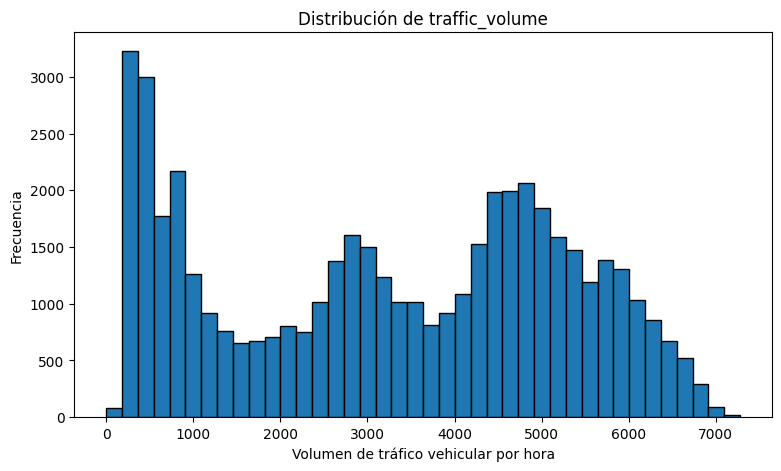

In [139]:
# =========================================================
# Histograma de la variable dependiente
# =========================================================

plt.figure(figsize=(9, 5))
plt.hist(dataset["traffic_volume"], bins=40, edgecolor="black")
plt.title("Distribución de traffic_volume")
plt.xlabel("Volumen de tráfico vehicular por hora")
plt.ylabel("Frecuencia")
plt.show()

El histograma de `traffic_volume` muestra que el tráfico no se concentra en un único valor. Existen registros con tráfico bajo, medio y alto. Esto refleja distintos momentos del día y diferentes condiciones de circulación, lo cual es útil para entrenar un modelo de regresión.

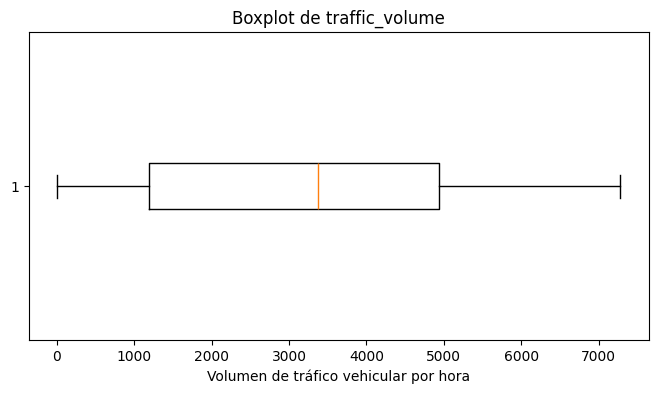

In [140]:
# =========================================================
# Boxplot de la variable dependiente
# =========================================================

plt.figure(figsize=(8, 4))
plt.boxplot(dataset["traffic_volume"], vert=False)
plt.title("Boxplot de traffic_volume")
plt.xlabel("Volumen de tráfico vehicular por hora")
plt.show()

El boxplot permite observar la amplitud de los valores de `traffic_volume`. Los valores bajos cercanos a cero y los valores altos superiores a 6000 vehículos por hora no deben eliminarse automáticamente, ya que pueden representar horarios reales de baja o alta circulación.

In [141]:
# =========================================================
# Distribución de variables categóricas
# =========================================================

categorical_cols = ["holiday", "weather_main", "weather_description"]

for col in categorical_cols:
    print(f"\nDistribución de {col}:")
    display(dataset[col].value_counts(dropna=False).head(15))


Distribución de holiday:


holiday
NaN                          48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64


Distribución de weather_main:


weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64


Distribución de weather_description:


weather_description
sky is clear               11665
mist                        5950
overcast clouds             5081
broken clouds               4666
scattered clouds            3461
light rain                  3372
few clouds                  1956
light snow                  1946
Sky is Clear                1726
moderate rain               1664
haze                        1360
light intensity drizzle     1100
fog                          912
proximity thunderstorm       673
drizzle                      651
Name: count, dtype: int64

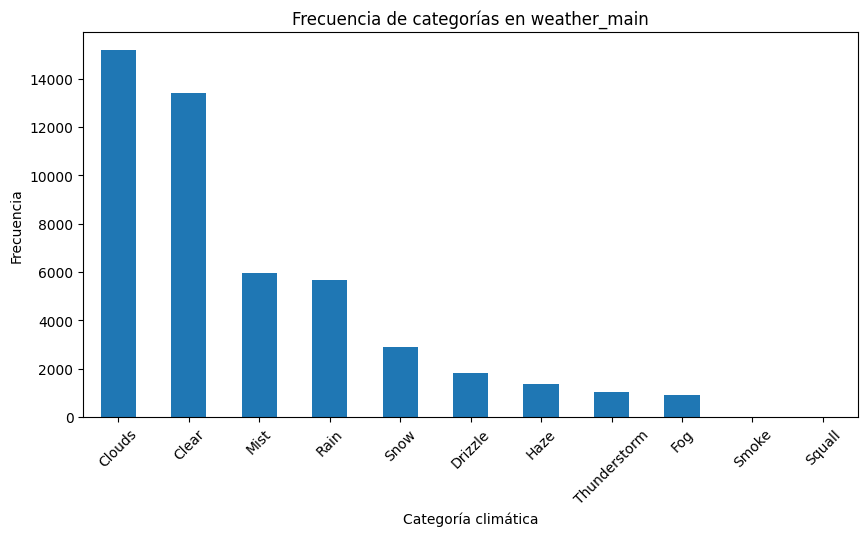

In [142]:
# =========================================================
# Gráfica de barras de weather_main
# =========================================================

plt.figure(figsize=(10, 5))
dataset["weather_main"].value_counts().plot(kind="bar")
plt.title("Frecuencia de categorías en weather_main")
plt.xlabel("Categoría climática")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

La variable `weather_main` muestra que las categorías más frecuentes son `Clouds` y `Clear`, seguidas de condiciones como `Mist`, `Rain` y `Snow`. Esto indica que las condiciones climáticas no aparecen con la misma frecuencia. Estas variables pueden aportar información al modelo, pero al ser categóricas deberán codificarse antes del entrenamiento.

In [143]:
# =========================================================
# Análisis temporal exploratorio
# Se crea una copia para analizar date_time sin modificar el dataset original
# =========================================================

dataset_eda = dataset.copy()
dataset_eda["date_time"] = pd.to_datetime(dataset_eda["date_time"])

dataset_eda["hour"] = dataset_eda["date_time"].dt.hour
dataset_eda["day_of_week"] = dataset_eda["date_time"].dt.dayofweek
dataset_eda["month"] = dataset_eda["date_time"].dt.month
dataset_eda["year"] = dataset_eda["date_time"].dt.year

dataset_eda[["date_time", "hour", "day_of_week", "month", "year", "traffic_volume"]].head()

,date_time,hour,day_of_week,month,year,traffic_volume
0,2012-10-02 09:00:00,9,1,10,2012,5545
1,2012-10-02 10:00:00,10,1,10,2012,4516
2,2012-10-02 11:00:00,11,1,10,2012,4767
3,2012-10-02 12:00:00,12,1,10,2012,5026
4,2012-10-02 13:00:00,13,1,10,2012,4918


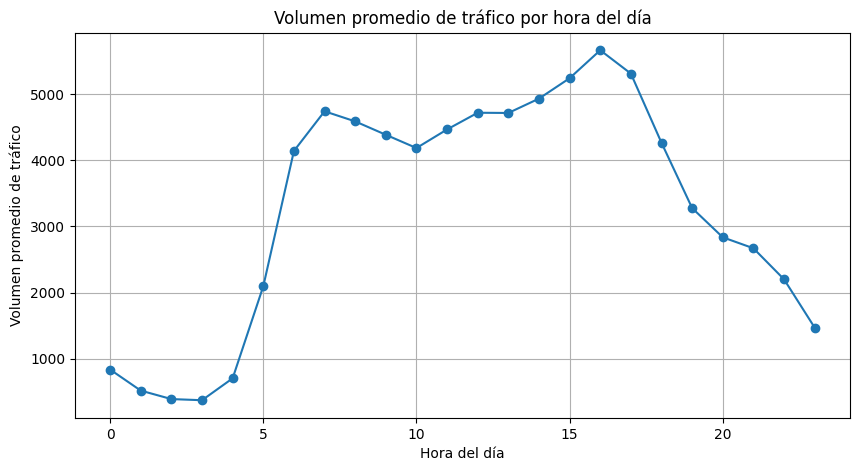

hour
0     834.781
1     516.449
2     388.354
3     371.091
4     702.552
5    2094.573
6    4140.504
7    4740.181
8    4587.497
9    4385.278
10   4184.666
11   4465.878
12   4718.293
13   4714.941
14   4931.889
15   5240.524
16   5663.757
17   5310.076
18   4263.719
19   3276.394
20   2834.668
21   2668.940
22   2199.406
23   1469.135
Name: traffic_volume, dtype: float64

In [144]:
# =========================================================
# Volumen promedio de tráfico por hora del día
# =========================================================

traffic_by_hour = dataset_eda.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10, 5))
traffic_by_hour.plot(kind="line", marker="o")
plt.title("Volumen promedio de tráfico por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Volumen promedio de tráfico")
plt.grid(True)
plt.show()

traffic_by_hour

La gráfica de tráfico promedio por hora muestra un patrón temporal claro. Durante la madrugada el volumen de tráfico es bajo, mientras que aumenta durante la mañana y la tarde. Esto sugiere que la hora del día será una variable muy importante para predecir el tráfico.

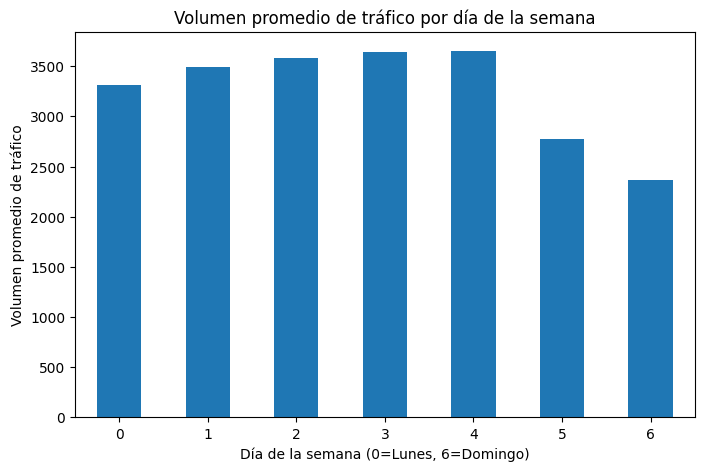

day_of_week
0   3309.387
1   3488.556
2   3583.197
3   3637.900
4   3656.359
5   2773.638
6   2368.588
Name: traffic_volume, dtype: float64

In [145]:
# =========================================================
# Volumen promedio de tráfico por día de la semana
# 0 = lunes, 6 = domingo
# =========================================================

traffic_by_day = dataset_eda.groupby("day_of_week")["traffic_volume"].mean()

plt.figure(figsize=(8, 5))
traffic_by_day.plot(kind="bar")
plt.title("Volumen promedio de tráfico por día de la semana")
plt.xlabel("Día de la semana (0=Lunes, 6=Domingo)")
plt.ylabel("Volumen promedio de tráfico")
plt.xticks(rotation=0)
plt.show()

traffic_by_day

El tráfico promedio cambia según el día de la semana. En general, los días laborales presentan mayor volumen de tráfico que el fin de semana. Esto indica que variables derivadas de `date_time`, como `day_of_week` e `is_weekend`, pueden ser relevantes para el modelo.

In [146]:
# =========================================================
# Relación entre weather_main y traffic_volume
# =========================================================

traffic_by_weather = dataset.groupby("weather_main")["traffic_volume"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
traffic_by_weather

,count,mean,median
weather_main,,,
Clouds,15164,3618.450,4072.000
Haze,1360,3502.101,3987.000
Rain,5672,3317.906,3497.500
Drizzle,1821,3290.727,3473.000
Smoke,20,3237.650,3612.000
Clear,13391,3055.909,3045.000
Snow,2876,3016.844,3080.000
Thunderstorm,1034,3001.621,2971.500
Mist,5950,2932.957,2800.000


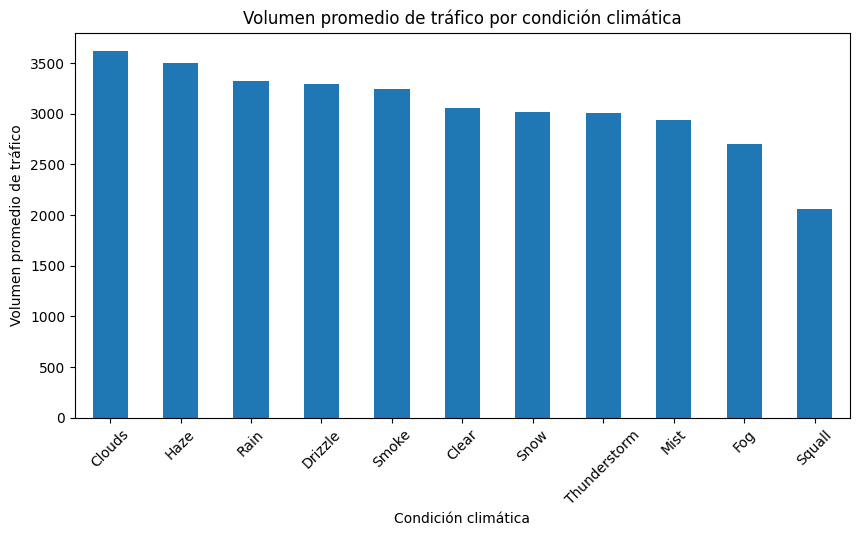

In [147]:
# =========================================================
# Gráfica de tráfico promedio por condición climática
# =========================================================

plt.figure(figsize=(10, 5))
traffic_by_weather["mean"].plot(kind="bar")
plt.title("Volumen promedio de tráfico por condición climática")
plt.xlabel("Condición climática")
plt.ylabel("Volumen promedio de tráfico")
plt.xticks(rotation=45)
plt.show()

El volumen promedio de tráfico cambia según la condición climática. Algunas categorías, como `Clouds` y `Haze`, presentan promedios más altos, mientras que otras como `Fog` o `Squall` tienen promedios menores. Sin embargo, algunas categorías aparecen con muy pocos registros, por lo que sus promedios deben interpretarse con cuidado.

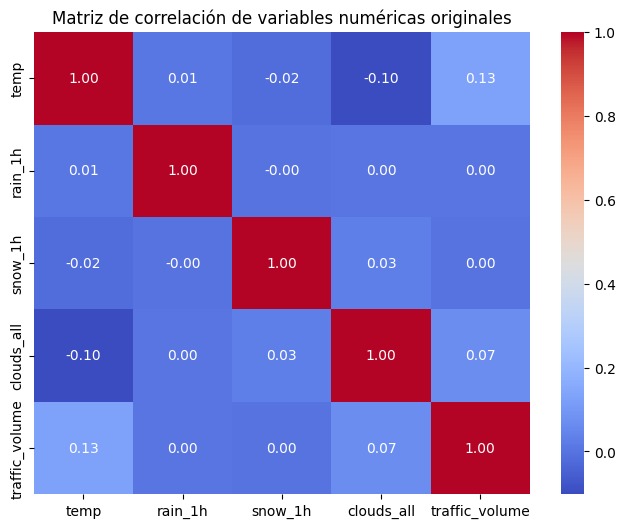

traffic_volume   1.000
temp             0.130
clouds_all       0.067
rain_1h          0.005
snow_1h          0.001
Name: traffic_volume, dtype: float64

In [148]:
# =========================================================
# Matriz de correlación de variables numéricas originales
# =========================================================

numeric_cols = dataset.select_dtypes(include=["int64", "float64"]).columns

correlation_matrix = dataset[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación de variables numéricas originales")
plt.show()

correlation_matrix["traffic_volume"].sort_values(ascending=False)

La matriz de correlación muestra que las variables numéricas originales tienen relaciones lineales moderadas o bajas con `traffic_volume`. La variable `temp` presenta una relación positiva mayor que las demás, aunque no es suficientemente alta para explicar por sí sola el volumen de tráfico.

Esto indica que la correlación lineal no debe ser el único criterio para seleccionar características. Es probable que variables temporales derivadas de `date_time` y modelos no lineales aporten mayor capacidad predictiva.

## 3.3 Preparación de los datos

En esta etapa se prepara el dataset para el modelado. Se definen las variables independientes `X` y la variable dependiente `y`, se tratan valores faltantes, se corrigen valores inválidos, se transforman variables temporales, se convierten variables categóricas y se define el preprocesamiento mediante `Pipeline` y `ColumnTransformer`.

In [149]:
# =========================================================
# 3.3 Preparación de los datos
# Librerías necesarias
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [150]:
# =========================================================
# Copia del dataset para preparación
# =========================================================

dataset_prep = dataset.copy()

print("Dimensiones originales:")
print(dataset_prep.shape)

# Eliminar duplicados exactos
duplicados_antes = dataset_prep.duplicated().sum()
dataset_prep = dataset_prep.drop_duplicates()

print(f"Duplicados exactos eliminados: {duplicados_antes}")
print("Dimensiones después de eliminar duplicados:")
print(dataset_prep.shape)

Dimensiones originales:
(48204, 9)
Duplicados exactos eliminados: 17
Dimensiones después de eliminar duplicados:
(48187, 9)


Se eliminaron los registros duplicados exactos porque pueden afectar el entrenamiento al repetir información idéntica. Esto evita que ciertos casos tengan más peso del necesario durante el aprendizaje del modelo.

In [151]:
# =========================================================
# Tratamiento de holiday
# Los valores nulos representan ausencia de día festivo
# =========================================================

print("Nulos en holiday antes del tratamiento:")
print(dataset_prep["holiday"].isnull().sum())

dataset_prep["holiday"] = dataset_prep["holiday"].fillna("None")

print("\nNulos en holiday después del tratamiento:")
print(dataset_prep["holiday"].isnull().sum())

print("\nDistribución de holiday:")
display(dataset_prep["holiday"].value_counts().head(10))

Nulos en holiday antes del tratamiento:
48126

Nulos en holiday después del tratamiento:
0

Distribución de holiday:


holiday
None                         48126
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Name: count, dtype: int64

Los valores faltantes de `holiday` no se interpretan como pérdida real de información, sino como ausencia de día festivo. Por ello, se reemplazaron por la categoría `None`.

In [152]:
# =========================================================
# Transformación de date_time a variables temporales
# =========================================================

dataset_prep["date_time"] = pd.to_datetime(dataset_prep["date_time"], errors="coerce")

# Revisar fechas inválidas
fechas_invalidas = dataset_prep["date_time"].isnull().sum()
print(f"Fechas inválidas encontradas: {fechas_invalidas}")

# Si existieran fechas inválidas, se eliminarían porque no se pueden recuperar
dataset_prep = dataset_prep.dropna(subset=["date_time"])

# Variables temporales derivadas
dataset_prep["hour"] = dataset_prep["date_time"].dt.hour
dataset_prep["day_of_week"] = dataset_prep["date_time"].dt.dayofweek
dataset_prep["month"] = dataset_prep["date_time"].dt.month
dataset_prep["year"] = dataset_prep["date_time"].dt.year
dataset_prep["is_weekend"] = dataset_prep["day_of_week"].isin([5, 6]).astype(int)

# Variable binaria para indicar si hay día festivo
dataset_prep["is_holiday"] = (dataset_prep["holiday"] != "None").astype(int)

dataset_prep[["date_time", "hour", "day_of_week", "month", "year", "is_weekend", "holiday", "is_holiday"]].head()

Fechas inválidas encontradas: 0


,date_time,hour,day_of_week,month,year,is_weekend,holiday,is_holiday
0,2012-10-02 09:00:00,9,1,10,2012,0,None,0
1,2012-10-02 10:00:00,10,1,10,2012,0,None,0
2,2012-10-02 11:00:00,11,1,10,2012,0,None,0
3,2012-10-02 12:00:00,12,1,10,2012,0,None,0
4,2012-10-02 13:00:00,13,1,10,2012,0,None,0


La variable `date_time` no se utilizará directamente como texto. En su lugar, se extrajeron variables temporales con significado predictivo: `hour`, `day_of_week`, `month`, `year` e `is_weekend`.

También se creó `is_holiday` para identificar si el registro corresponde o no a un día festivo.

In [153]:
# =========================================================
# Tratamiento de valores inválidos o extremos
# =========================================================

# temp = 0 Kelvin no es realista en este contexto, se tratará como valor faltante
temp_cero_antes = (dataset_prep["temp"] == 0).sum()
dataset_prep.loc[dataset_prep["temp"] == 0, "temp"] = np.nan

# rain_1h extremadamente alto se tratará como valor faltante
# Umbral razonable para evitar que un valor extremo distorsione el modelado
rain_extrema_antes = (dataset_prep["rain_1h"] > 100).sum()
dataset_prep.loc[dataset_prep["rain_1h"] > 100, "rain_1h"] = np.nan

print(f"Registros con temp = 0 tratados como NaN: {temp_cero_antes}")
print(f"Registros con rain_1h > 100 tratados como NaN: {rain_extrema_antes}")

print("\nNulos después de tratar valores inválidos:")
display(dataset_prep.isnull().sum())

Registros con temp = 0 tratados como NaN: 10
Registros con rain_1h > 100 tratados como NaN: 1

Nulos después de tratar valores inválidos:


holiday                 0
temp                   10
rain_1h                 1
snow_1h                 0
clouds_all              0
weather_main            0
weather_description     0
date_time               0
traffic_volume          0
hour                    0
day_of_week             0
month                   0
year                    0
is_weekend              0
is_holiday              0
dtype: int64

Los valores `temp = 0` Kelvin se consideran inválidos para este contexto y se marcaron como valores faltantes. También se trató como valor faltante un valor extremo en `rain_1h`, ya que podía distorsionar las estadísticas y afectar modelos sensibles a escala.

In [154]:
# =========================================================
# Generación de valores faltantes artificiales
# =========================================================

# Debido a que el dataset no tiene valores faltantes reales en la mayoría de X,
# se generan nulos artificiales de forma reproducible en variables independientes.

SEED = 42
rng = np.random.default_rng(SEED)

columnas_nulos_artificiales = ["temp", "clouds_all"]
porcentaje_nulos = 0.05

for col in columnas_nulos_artificiales:
    mask = rng.random(len(dataset_prep)) < porcentaje_nulos
    dataset_prep.loc[mask, col] = np.nan

tabla_nulos_preparacion = pd.DataFrame({
    "Nulos": dataset_prep.isnull().sum(),
    "Porcentaje": (dataset_prep.isnull().mean() * 100).round(2)
})

tabla_nulos_preparacion

,Nulos,Porcentaje
holiday,0,0.000
temp,2409,5.000
rain_1h,1,0.000
snow_1h,0,0.000
clouds_all,2456,5.100
weather_main,0,0.000
weather_description,0,0.000
date_time,0,0.000
traffic_volume,0,0.000
hour,0,0.000


Se generaron valores faltantes artificiales en las variables independientes `temp` y `clouds_all`, usando una semilla fija para que el proceso sea reproducible. El porcentaje introducido fue aproximadamente del 5% en cada variable.

La variable dependiente `traffic_volume` no fue modificada, evitando alterar el objetivo de predicción.

In [155]:
# =========================================================
# Definición de variables independientes X y variable dependiente y
# =========================================================

target = "traffic_volume"

# Columnas que no deben entrar a X
# traffic_volume: es la variable objetivo
# date_time: se reemplazó por variables temporales derivadas
columnas_excluir = ["traffic_volume", "date_time"]

X = dataset_prep.drop(columns=columnas_excluir)
y = dataset_prep[target]

print("Dimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

print("\nColumnas utilizadas como variables independientes:")
print(X.columns.tolist())

print("\nVariable dependiente:")
print(target)

Dimensiones de X:
(48187, 13)

Dimensiones de y:
(48187,)

Columnas utilizadas como variables independientes:
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday']

Variable dependiente:
traffic_volume


La variable dependiente es `traffic_volume`, que representa el volumen horario de tráfico vehicular. Las variables independientes `X` incluyen información climática, de días festivos y variables temporales derivadas.

No se incluye `traffic_volume` dentro de `X` para evitar fuga de datos. Tampoco se incluye `date_time` directamente, ya que fue transformada en variables temporales interpretables.

In [156]:
# =========================================================
# Identificación de variables numéricas y categóricas
# =========================================================

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

print(f"\nCantidad de variables numéricas: {len(numeric_features)}")
print(f"Cantidad de variables categóricas: {len(categorical_features)}")

Variables numéricas:
['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday']

Variables categóricas:
['holiday', 'weather_main', 'weather_description']

Cantidad de variables numéricas: 10
Cantidad de variables categóricas: 3


In [157]:
# =========================================================
# Conteo estimado de columnas antes y después de OneHotEncoder
# =========================================================

columnas_antes = X.shape[1]

categorias_por_columna = {
    col: X[col].nunique(dropna=True)
    for col in categorical_features
}

columnas_generadas_categoricas = sum(categorias_por_columna.values())
columnas_despues_onehot = len(numeric_features) + columnas_generadas_categoricas

print(f"Columnas independientes antes de codificación: {columnas_antes}")
print("\nCategorías por variable categórica:")
print(categorias_por_columna)

print(f"\nColumnas categóricas generadas por OneHotEncoder: {columnas_generadas_categoricas}")
print(f"Columnas estimadas después de codificación: {columnas_despues_onehot}")

Columnas independientes antes de codificación: 13

Categorías por variable categórica:
{'holiday': 12, 'weather_main': 11, 'weather_description': 38}

Columnas categóricas generadas por OneHotEncoder: 61
Columnas estimadas después de codificación: 71


Las variables categóricas `holiday`, `weather_main` y `weather_description` son nominales. Por esta razón, se utilizará `OneHotEncoder`, ya que no existe un orden natural entre sus categorías.

No se utiliza codificación ordinal porque asignaría un orden artificial a categorías climáticas como `Clear`, `Clouds`, `Rain` o `Snow`.

In [158]:
# =========================================================
# Preprocesamiento con Pipeline y ColumnTransformer
# =========================================================

# Compatibilidad para diferentes versiones de scikit-learn
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Pipeline para variables numéricas:
# 1. Imputación con mediana
# 2. Escalado con StandardScaler
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variables categóricas:
# 1. Imputación con moda
# 2. Codificación OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

# ColumnTransformer para aplicar transformaciones por tipo de variable
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

El preprocesamiento se definió mediante `Pipeline` y `ColumnTransformer`. Esto permite aplicar imputación, codificación y escalado de forma ordenada y evita fuga de información durante la validación cruzada.

La imputación numérica se realizará con la mediana, porque es más resistente a valores extremos. Las variables categóricas se imputarán con la moda y posteriormente se convertirán con `OneHotEncoder`.

El escalado se realizará con `StandardScaler`, especialmente porque será necesario para PCA y para el modelo de red neuronal `MLPRegressor`.

In [159]:
# =========================================================
# Verificación del preprocesador con una muestra pequeña
# Esta prueba solo confirma que las transformaciones funcionan.
# El preprocesador se ajustará correctamente dentro de los pipelines
# durante validación cruzada y modelado.
# =========================================================

muestra_X = X.head(10)
muestra_transformada = preprocessor.fit_transform(muestra_X)

print("Forma de la muestra original:")
print(muestra_X.shape)

print("\nForma de la muestra transformada:")
print(muestra_transformada.shape)

Forma de la muestra original:
(10, 13)

Forma de la muestra transformada:
(10, 18)


## 3.4 Selección y transformación de características

En esta etapa se construyen dos representaciones del dataset:

1. **Escenario 1:** características seleccionadas mediante correlación, RFE e importancia con árboles.
2. **Escenario 2:** componentes principales obtenidos mediante PCA.

La selección de características se realizará considerando conjuntamente los tres métodos, y PCA se incorporará posteriormente dentro de los pipelines para evitar fuga de información.

In [160]:
# =========================================================
# 3.4 Selección y transformación de características
# Librerías necesarias
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.decomposition import PCA

In [161]:
# =========================================================
# Separación para análisis de características
# =========================================================

# Se utiliza una partición de entrenamiento para analizar características.
# Esto evita usar toda la información del dataset al decidir qué variables seleccionar.

X_analysis, X_holdout, y_analysis, y_holdout = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)

print("Dimensiones de X_analysis:")
print(X_analysis.shape)

print("\nDimensiones de X_holdout:")
print(X_holdout.shape)

Dimensiones de X_analysis:
(38549, 13)

Dimensiones de X_holdout:
(9638, 13)


Para reducir el riesgo de fuga de información, el análisis de selección de características se realiza sobre una partición de entrenamiento llamada `X_analysis`. La partición `X_holdout` no se utiliza para decidir las características.

In [162]:
# =========================================================
# Ajustar el preprocesador solo con X_analysis
# =========================================================

X_analysis_transformed = preprocessor.fit_transform(X_analysis)

# Obtener nombres de características después del preprocesamiento
feature_names_transformed = preprocessor.get_feature_names_out()

X_analysis_transformed_df = pd.DataFrame(
    X_analysis_transformed,
    columns=feature_names_transformed,
    index=X_analysis.index
)

print("Número de variables originales en X:")
print(X.shape[1])

print("\nNúmero de variables después de imputación, escalado y OneHotEncoder:")
print(X_analysis_transformed_df.shape[1])

X_analysis_transformed_df.head()

Número de variables originales en X:
13

Número de variables después de imputación, escalado y OneHotEncoder:
71


,num__temp,num__rain_1h,num__snow_1h,num__clouds_all,num__hour,num__day_of_week,num__month,num__year,num__is_weekend,num__is_holiday,cat__holiday_Christmas Day,cat__holiday_Columbus Day,cat__holiday_Independence Day,cat__holiday_Labor Day,cat__holiday_Martin Luther King Jr Day,cat__holiday_Memorial Day,cat__holiday_New Years Day,cat__holiday_None,cat__holiday_State Fair,cat__holiday_Thanksgiving Day,cat__holiday_Veterans Day,cat__holiday_Washingtons Birthday,cat__weather_main_Clear,cat__weather_main_Clouds,cat__weather_main_Drizzle,cat__weather_main_Fog,cat__weather_main_Haze,cat__weather_main_Mist,cat__weather_main_Rain,cat__weather_main_Smoke,cat__weather_main_Snow,cat__weather_main_Squall,cat__weather_main_Thunderstorm,cat__weather_description_SQUALLS,cat__weather_description_Sky is Clear,cat__weather_description_broken clouds,cat__weather_description_drizzle,cat__weather_description_few clouds,cat__weather_description_fog,cat__weather_description_freezing rain,cat__weather_description_haze,cat__weather_description_heavy intensity drizzle,cat__weather_description_heavy intensity rain,cat__weather_description_heavy snow,cat__weather_description_light intensity drizzle,cat__weather_description_light intensity shower rain,cat__weather_description_light rain,cat__weather_description_light rain and snow,cat__weather_description_light shower snow,cat__weather_description_light snow,cat__weather_description_mist,cat__weather_description_moderate rain,cat__weather_description_overcast clouds,cat__weather_description_proximity shower rain,cat__weather_description_proximity thunderstorm,cat__weather_description_proximity thunderstorm with drizzle,cat__weather_description_proximity thunderstorm with rain,cat__weather_description_scattered clouds,cat__weather_description_shower drizzle,cat__weather_description_shower snow,cat__weather_description_sky is clear,cat__weather_description_sleet,cat__weather_description_smoke,cat__weather_description_snow,cat__weather_description_thunderstorm,cat__weather_description_thunderstorm with drizzle,cat__weather_description_thunderstorm with heavy rain,cat__weather_description_thunderstorm with light drizzle,cat__weather_description_thunderstorm with light rain,cat__weather_description_thunderstorm with rain,cat__weather_description_very heavy rain
44765,1.139,-0.131,-0.028,1.047,1.380,0.007,-0.153,1.316,-0.631,-0.036,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8090,0.799,-0.131,-0.028,0.366,1.668,-0.491,0.142,-1.326,-0.631,-0.036,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
33257,-0.362,-0.131,-0.028,1.047,0.085,-1.487,-0.447,0.788,-0.631,-0.036,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
33820,0.085,-0.131,-0.028,0.366,-1.067,1.004,-0.447,0.788,1.584,-0.036,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00

In [163]:
# =========================================================
# Función para identificar la variable original
# a partir del nombre transformado
# =========================================================

def obtener_variable_original(nombre_transformado):
    """
    Convierte nombres como:
    num__temp -> temp
    cat__weather_main_Clear -> weather_main
    cat__weather_description_sky is clear -> weather_description
    """
    if nombre_transformado.startswith("num__"):
        return nombre_transformado.replace("num__", "")
    
    if nombre_transformado.startswith("cat__"):
        nombre = nombre_transformado.replace("cat__", "")
        for col in categorical_features:
            if nombre.startswith(col + "_"):
                return col
    
    return nombre_transformado

variables_originales_transformadas = [
    obtener_variable_original(col) for col in X_analysis_transformed_df.columns
]

tabla_mapeo = pd.DataFrame({
    "Característica transformada": X_analysis_transformed_df.columns,
    "Variable original": variables_originales_transformadas
})

tabla_mapeo.head(20)

,Característica transformada,Variable original
0,num__temp,temp
1,num__rain_1h,rain_1h
2,num__snow_1h,snow_1h
3,num__clouds_all,clouds_all
4,num__hour,hour
5,num__day_of_week,day_of_week
6,num__month,month
7,num__year,year
8,num__is_weekend,is_weekend
9,num__is_holiday,is_holiday


### Matriz de correlación

Se analiza la correlación entre las variables transformadas y la variable dependiente `traffic_volume`. En variables categóricas convertidas con OneHotEncoder, se agrupa la correlación de sus columnas binarias para identificar la relación aproximada de la variable original con el objetivo.

In [164]:
# =========================================================
# Correlación entre variables transformadas y y
# =========================================================

correlaciones = {}

for col in X_analysis_transformed_df.columns:
    x_col = X_analysis_transformed_df[col]
    if x_col.std() == 0:
        correlaciones[col] = 0
    else:
        correlaciones[col] = np.corrcoef(x_col, y_analysis)[0, 1]

corr_df = pd.DataFrame({
    "Característica transformada": list(correlaciones.keys()),
    "Correlación": list(correlaciones.values())
})

corr_df["Correlación absoluta"] = corr_df["Correlación"].abs()
corr_df["Variable original"] = corr_df["Característica transformada"].apply(obtener_variable_original)

corr_df = corr_df.sort_values("Correlación absoluta", ascending=False)

corr_df.head(20)

,Característica transformada,Correlación,Correlación absoluta,Variable original
4,num__hour,0.350,0.350,hour
8,num__is_weekend,-0.221,0.221,is_weekend
5,num__day_of_week,-0.151,0.151,day_of_week
0,num__temp,0.128,0.128,temp
23,cat__weather_main_Clouds,0.123,0.123,weather_main
57,cat__weather_description_scattered clouds,0.088,0.088,weather_description
60,cat__weather_description_sky is clear,-0.075,0.075,weather_description
3,num__clouds_all,0.065,0.065,clouds_all
22,cat__weather_main_Clear,-0.065,0.065,weather_main
35,cat__weather_description_broken clouds,0.064,0.064,weather_description


In [165]:
# =========================================================
# Correlación agrupada por variable original
# =========================================================

corr_grouped = (
    corr_df
    .groupby("Variable original")
    .agg(
        correlacion_max_abs=("Correlación absoluta", "max"),
        correlacion_promedio_abs=("Correlación absoluta", "mean")
    )
    .sort_values("correlacion_max_abs", ascending=False)
    .reset_index()
)

corr_grouped

,Variable original,correlacion_max_abs,correlacion_promedio_abs
0,hour,0.350,0.350
1,is_weekend,0.221,0.221
2,day_of_week,0.151,0.151
3,temp,0.128,0.128
4,weather_main,0.123,0.034
5,weather_description,0.088,0.018
6,clouds_all,0.065,0.065
7,holiday,0.043,0.015
8,is_holiday,0.043,0.043
9,rain_1h,0.021,0.021


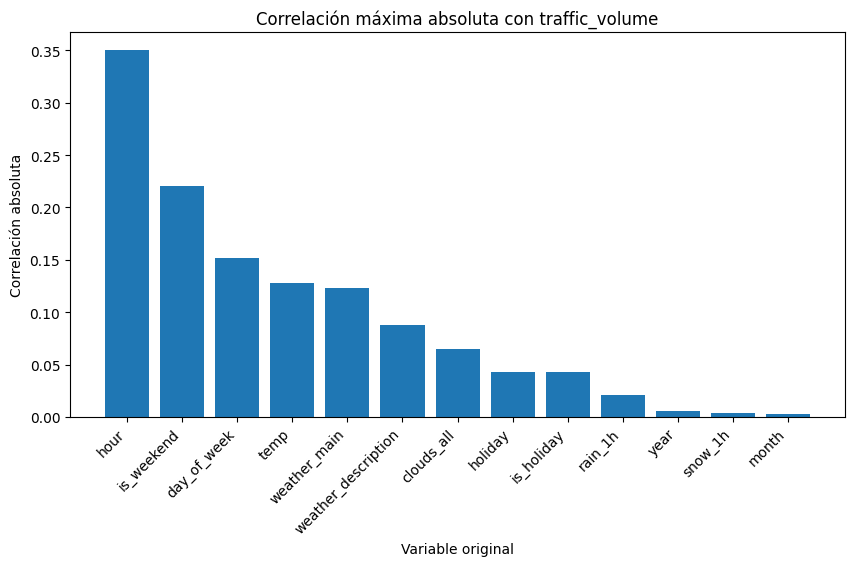

In [166]:
# =========================================================
# Gráfica de correlación máxima absoluta por variable original
# =========================================================

plt.figure(figsize=(10, 5))
plt.bar(corr_grouped["Variable original"], corr_grouped["correlacion_max_abs"])
plt.title("Correlación máxima absoluta con traffic_volume")
plt.xlabel("Variable original")
plt.ylabel("Correlación absoluta")
plt.xticks(rotation=45, ha="right")
plt.show()

La correlación permite identificar relaciones lineales con `traffic_volume`. Las variables temporales suelen destacar porque el tráfico cambia de forma importante según la hora del día y el día de la semana.

Sin embargo, la correlación no debe ser el único criterio de selección, ya que no detecta correctamente relaciones no lineales. Por esa razón se complementa con RFE y con importancia de características mediante árboles.

### Recursive Feature Elimination, RFE

Se aplica RFE utilizando `LinearRegression` como estimador base. Este estimador es compatible con RFE porque genera coeficientes para las variables de entrada, lo que permite ordenar las características y eliminar las menos relevantes de forma iterativa.

In [167]:
# =========================================================
# Recursive Feature Elimination, RFE
# =========================================================

rfe_estimator = LinearRegression()

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=12
)

rfe.fit(X_analysis_transformed_df, y_analysis)

rfe_df = pd.DataFrame({
    "Característica transformada": X_analysis_transformed_df.columns,
    "Variable original": [obtener_variable_original(col) for col in X_analysis_transformed_df.columns],
    "Seleccionada por RFE": rfe.support_,
    "Ranking RFE": rfe.ranking_
})

rfe_df = rfe_df.sort_values(["Ranking RFE", "Variable original"])

rfe_df.head(30)

,Característica transformada,Variable original,Seleccionada por RFE,Ranking RFE
10,cat__holiday_Christmas Day,holiday,True,1
11,cat__holiday_Columbus Day,holiday,True,1
12,cat__holiday_Independence Day,holiday,True,1
13,cat__holiday_Labor Day,holiday,True,1
14,cat__holiday_Martin Luther King Jr Day,holiday,True,1
16,cat__holiday_New Years Day,holiday,True,1
18,cat__holiday_State Fair,holiday,True,1
19,cat__holiday_Thanksgiving Day,holiday,True,1
20,cat__holiday_Veterans Day,holiday,True,1
21,cat__holiday_Washingtons Birthday,holiday,True,1


In [168]:
# =========================================================
# Resumen de RFE agrupado por variable original
# =========================================================

rfe_grouped = (
    rfe_df
    .groupby("Variable original")
    .agg(
        seleccionada_rfe=("Seleccionada por RFE", "max"),
        mejor_ranking_rfe=("Ranking RFE", "min")
    )
    .sort_values(["seleccionada_rfe", "mejor_ranking_rfe"], ascending=[False, True])
    .reset_index()
)

rfe_grouped

,Variable original,seleccionada_rfe,mejor_ranking_rfe
0,holiday,True,1
1,weather_description,True,1
2,weather_main,False,3
3,hour,False,12
4,is_weekend,False,15
5,temp,False,29
6,day_of_week,False,33
7,clouds_all,False,39
8,is_holiday,False,49
9,month,False,51


RFE permite analizar la utilidad de las variables dentro de un modelo supervisado. A diferencia de la correlación, este método considera la relación de las variables con el objetivo durante el ajuste del estimador.

Las variables con ranking 1 fueron las más relevantes para el estimador utilizado. Sin embargo, como RFE depende del modelo base, sus resultados deben compararse con otros métodos antes de tomar una decisión final.

### Importancia de características mediante árboles

Se utiliza `ExtraTreesRegressor` para calcular la importancia de características. Este modelo basado en árboles puede capturar relaciones no lineales y asignar importancia a las variables según su contribución a la reducción del error.

In [169]:
# =========================================================
# Importancia de características mediante árboles
# =========================================================

tree_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

tree_model.fit(X_analysis_transformed_df, y_analysis)

importance_df = pd.DataFrame({
    "Característica transformada": X_analysis_transformed_df.columns,
    "Variable original": [obtener_variable_original(col) for col in X_analysis_transformed_df.columns],
    "Importancia": tree_model.feature_importances_
})

importance_df = importance_df.sort_values("Importancia", ascending=False)

importance_df.head(30)

,Característica transformada,Variable original,Importancia
4,num__hour,hour,0.847
8,num__is_weekend,is_weekend,0.064
5,num__day_of_week,day_of_week,0.021
0,num__temp,temp,0.019
6,num__month,month,0.013
7,num__year,year,0.011
3,num__clouds_all,clouds_all,0.005
1,num__rain_1h,rain_1h,0.003
23,cat__weather_main_Clouds,weather_main,0.003
30,cat__weather_main_Snow,weather_main,0.001


In [170]:
# =========================================================
# Importancia agrupada por variable original
# =========================================================

importance_grouped = (
    importance_df
    .groupby("Variable original")
    .agg(importancia_arboles=("Importancia", "sum"))
    .sort_values("importancia_arboles", ascending=False)
    .reset_index()
)

importance_grouped

,Variable original,importancia_arboles
0,hour,0.847
1,is_weekend,0.064
2,day_of_week,0.021
3,temp,0.019
4,month,0.013
5,year,0.011
6,weather_description,0.010
7,weather_main,0.007
8,clouds_all,0.005
9,rain_1h,0.003


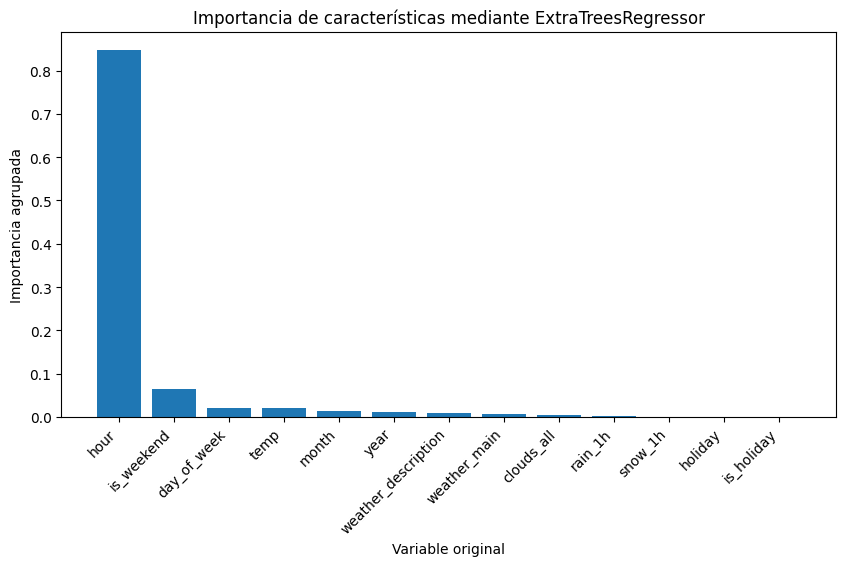

In [171]:
# =========================================================
# Gráfica de importancia mediante árboles
# =========================================================

plt.figure(figsize=(10, 5))
plt.bar(importance_grouped["Variable original"], importance_grouped["importancia_arboles"])
plt.title("Importancia de características mediante ExtraTreesRegressor")
plt.xlabel("Variable original")
plt.ylabel("Importancia agrupada")
plt.xticks(rotation=45, ha="right")
plt.show()

La importancia mediante árboles permite detectar variables útiles aunque su relación con `traffic_volume` no sea estrictamente lineal. Por ello, este método complementa la matriz de correlación y RFE.

Las variables con mayor importancia agrupada se consideran candidatas fuertes para el escenario de características seleccionadas.

### Selección final de características

La selección final se realiza comparando los resultados de correlación, RFE e importancia mediante árboles. También se considera la interpretabilidad de las variables y su utilidad para el despliegue posterior en una aplicación web.

In [172]:
# =========================================================
# Tabla comparativa de métodos de selección
# =========================================================

tabla_seleccion = (
    corr_grouped
    .merge(rfe_grouped, on="Variable original", how="outer")
    .merge(importance_grouped, on="Variable original", how="outer")
)

tabla_seleccion["correlacion_max_abs"] = tabla_seleccion["correlacion_max_abs"].fillna(0)
tabla_seleccion["correlacion_promedio_abs"] = tabla_seleccion["correlacion_promedio_abs"].fillna(0)
tabla_seleccion["seleccionada_rfe"] = tabla_seleccion["seleccionada_rfe"].fillna(False)
tabla_seleccion["mejor_ranking_rfe"] = tabla_seleccion["mejor_ranking_rfe"].fillna(999).astype(int)
tabla_seleccion["importancia_arboles"] = tabla_seleccion["importancia_arboles"].fillna(0)

tabla_seleccion = tabla_seleccion.sort_values(
    ["importancia_arboles", "correlacion_max_abs"],
    ascending=False
)

tabla_seleccion

,Variable original,correlacion_max_abs,correlacion_promedio_abs,seleccionada_rfe,mejor_ranking_rfe,importancia_arboles
3,hour,0.350,0.350,False,12,0.847
5,is_weekend,0.221,0.221,False,15,0.064
1,day_of_week,0.151,0.151,False,33,0.021
9,temp,0.128,0.128,False,29,0.019
6,month,0.003,0.003,False,51,0.013
12,year,0.005,0.005,False,59,0.011
10,weather_description,0.088,0.018,True,1,0.010
11,weather_main,0.123,0.034,False,3,0.007
0,clouds_all,0.065,0.065,False,39,0.005
7,rain_1h,0.021,0.021,False,52,0.003


In [173]:
# =========================================================
# Selección final de características
# =========================================================

selected_features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "temp",
    "clouds_all",
    "weather_main"
]

tabla_seleccion["Decisión"] = tabla_seleccion["Variable original"].apply(
    lambda x: "Incluir" if x in selected_features else "Excluir"
)

tabla_seleccion_final = tabla_seleccion[
    [
        "Variable original",
        "correlacion_max_abs",
        "seleccionada_rfe",
        "mejor_ranking_rfe",
        "importancia_arboles",
        "Decisión"
    ]
].copy()

tabla_seleccion_final

,Variable original,correlacion_max_abs,seleccionada_rfe,mejor_ranking_rfe,importancia_arboles,Decisión
3,hour,0.350,False,12,0.847,Incluir
5,is_weekend,0.221,False,15,0.064,Incluir
1,day_of_week,0.151,False,33,0.021,Incluir
9,temp,0.128,False,29,0.019,Incluir
6,month,0.003,False,51,0.013,Excluir
12,year,0.005,False,59,0.011,Excluir
10,weather_description,0.088,True,1,0.010,Excluir
11,weather_main,0.123,False,3,0.007,Incluir
0,clouds_all,0.065,False,39,0.005,Incluir
7,rain_1h,0.021,False,52,0.003,Excluir


In [174]:
# =========================================================
# Escenario 1: X con características seleccionadas
# =========================================================

X_selected = X[selected_features].copy()

numeric_features_selected = X_selected.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_selected = X_selected.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Características seleccionadas:")
print(selected_features)

print("\nVariables numéricas seleccionadas:")
print(numeric_features_selected)

print("\nVariables categóricas seleccionadas:")
print(categorical_features_selected)

print("\nDimensiones de X_selected:")
print(X_selected.shape)

Características seleccionadas:
['hour', 'day_of_week', 'is_weekend', 'temp', 'clouds_all', 'weather_main']

Variables numéricas seleccionadas:
['hour', 'day_of_week', 'is_weekend', 'temp', 'clouds_all']

Variables categóricas seleccionadas:
['weather_main']

Dimensiones de X_selected:
(48187, 6)


In [175]:
# =========================================================
# Preprocesador para el escenario de características seleccionadas
# =========================================================

try:
    onehot_selected = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_selected = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer_selected = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_selected = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot_selected)
])

preprocessor_selected = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_selected, numeric_features_selected),
        ("cat", categorical_transformer_selected, categorical_features_selected)
    ],
    remainder="drop"
)

preprocessor_selected

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

La selección final contiene seis características: `hour`, `day_of_week`, `is_weekend`, `temp`, `clouds_all` y `weather_main`.

Estas variables fueron seleccionadas porque combinan información temporal y climática relevante para explicar el volumen de tráfico. Las variables temporales representan patrones de movilidad, mientras que las variables climáticas aportan contexto ambiental.

Se excluyó `weather_description` porque es una variable más detallada que genera más columnas después de OneHotEncoder y puede dificultar la interpretación. Se prefirió `weather_main` porque resume de forma más clara la condición climática general.

### Escenario 2: Análisis de Componentes Principales, PCA

PCA se aplicará después de imputar valores faltantes, convertir variables categóricas y escalar variables numéricas. Este análisis permite conocer cuántos componentes son necesarios para conservar entre el 90% y el 95% de la varianza total.

En la evaluación de modelos, PCA se integrará dentro de un pipeline para evitar fuga de información.

In [176]:
# =========================================================
# Análisis de PCA sobre datos preprocesados
# =========================================================

# Se utiliza la matriz ya preprocesada de X_analysis
pca_analysis = PCA(random_state=SEED)
pca_analysis.fit(X_analysis_transformed_df)

explained_variance = pca_analysis.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

tabla_pca = pd.DataFrame({
    "Componente": np.arange(1, len(explained_variance) + 1),
    "Varianza explicada": explained_variance,
    "Varianza acumulada": cumulative_variance
})

tabla_pca.head(20)

,Componente,Varianza explicada,Varianza acumulada
0,1,0.154,0.154
1,2,0.117,0.271
2,3,0.110,0.381
3,4,0.095,0.476
4,5,0.090,0.566
5,6,0.086,0.651
6,7,0.083,0.735
7,8,0.077,0.812
8,9,0.055,0.867
9,10,0.026,0.892


In [177]:
# =========================================================
# Componentes necesarios para conservar 90% y 95% de varianza
# =========================================================

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Número de variables antes de PCA: {X_analysis_transformed_df.shape[1]}")
print(f"Número total de componentes generados: {len(explained_variance)}")
print(f"Componentes necesarios para 90% de varianza: {n_components_90}")
print(f"Componentes necesarios para 95% de varianza: {n_components_95}")

# Criterio recomendado: conservar 95% de la varianza
n_components_pca = n_components_95

print(f"\nNúmero de componentes conservados para el proyecto: {n_components_pca}")

Número de variables antes de PCA: 71
Número total de componentes generados: 71
Componentes necesarios para 90% de varianza: 11
Componentes necesarios para 95% de varianza: 14

Número de componentes conservados para el proyecto: 14


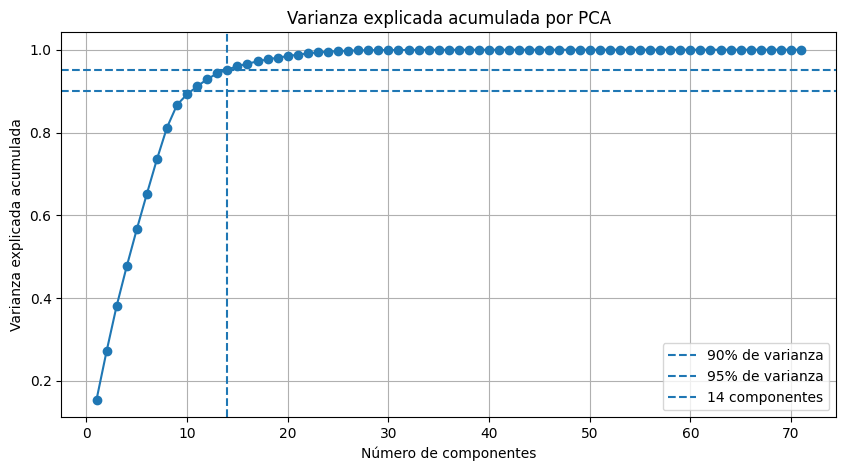

In [178]:
# =========================================================
# Gráfica de varianza explicada acumulada
# =========================================================

plt.figure(figsize=(10, 5))
plt.plot(
    tabla_pca["Componente"],
    tabla_pca["Varianza acumulada"],
    marker="o"
)

plt.axhline(y=0.90, linestyle="--", label="90% de varianza")
plt.axhline(y=0.95, linestyle="--", label="95% de varianza")
plt.axvline(x=n_components_pca, linestyle="--", label=f"{n_components_pca} componentes")

plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.legend()
plt.grid(True)
plt.show()

In [179]:
# =========================================================
# Reducción de dimensionalidad con PCA
# =========================================================

variables_antes_pca = X_analysis_transformed_df.shape[1]
variables_despues_pca = n_components_pca
reduccion = variables_antes_pca - variables_despues_pca
porcentaje_reduccion = (reduccion / variables_antes_pca) * 100

print(f"Variables antes de PCA: {variables_antes_pca}")
print(f"Componentes conservados: {variables_despues_pca}")
print(f"Reducción de dimensionalidad: {reduccion} variables/componentes")
print(f"Porcentaje de reducción: {porcentaje_reduccion:.2f}%")

Variables antes de PCA: 71
Componentes conservados: 14
Reducción de dimensionalidad: 57 variables/componentes
Porcentaje de reducción: 80.28%


In [180]:
# =========================================================
# Objeto PCA para usar posteriormente dentro de los pipelines
# =========================================================

pca = PCA(n_components=n_components_pca, random_state=SEED)

pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",np.int64(14)
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for rand

PCA permitió identificar cuántos componentes principales son necesarios para conservar la mayor parte de la varianza del conjunto preprocesado. Se seleccionó el número de componentes necesario para conservar aproximadamente el 95% de la varianza total.

La ventaja de PCA es que puede reducir la dimensionalidad y compactar la información. Sin embargo, su principal desventaja es que reduce la interpretabilidad, ya que los componentes principales no corresponden directamente a variables originales, sino a combinaciones matemáticas de ellas.

Por esta razón, PCA será evaluado como un segundo escenario y se comparará contra el escenario de características seleccionadas.

## 3.5 Modelado

En esta etapa se definen los tres algoritmos de regresión que se evaluarán en los dos escenarios del proyecto:

1. **Características seleccionadas**
2. **PCA**

Los modelos seleccionados son:

- `DecisionTreeRegressor`
- `RandomForestRegressor`
- `MLPRegressor`

Se incluye `MLPRegressor` porque la actividad solicita que al menos uno de los modelos sea una red neuronal.

In [181]:
# =========================================================
# 3.5 Modelado
# Importación de modelos y herramientas
# =========================================================

import time

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.base import clone

In [182]:
# =========================================================
# Definición de los tres algoritmos de regresión
# =========================================================

modelos = {
    "DecisionTreeRegressor": DecisionTreeRegressor(
        random_state=SEED,
        max_depth=18,
        min_samples_leaf=5
    ),
    
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=50,
        random_state=SEED,
        max_depth=22,
        min_samples_leaf=2,
        n_jobs=-1
    ),
    
    "MLPRegressor": MLPRegressor(
    hidden_layer_sizes=(50, 25),
    activation="relu",
    solver="adam",
    max_iter=500,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=15,
    tol=1e-4,
    random_state=SEED
)
}

modelos

{'DecisionTreeRegressor': DecisionTreeRegressor(max_depth=18, min_samples_leaf=5, random_state=42),
 'RandomForestRegressor': RandomForestRegressor(max_depth=22, min_samples_leaf=2, n_estimators=50,
                       n_jobs=-1, random_state=42),
 'MLPRegressor': MLPRegressor(early_stopping=True, hidden_layer_sizes=(50, 25), max_iter=500,
              n_iter_no_change=15, random_state=42)}

Se seleccionaron tres modelos de regresión. `DecisionTreeRegressor` y `RandomForestRegressor` son modelos basados en árboles, adecuados para capturar relaciones no lineales. `MLPRegressor` corresponde a una red neuronal multicapa, cumpliendo con el requisito de incluir un modelo neuronal.

In [183]:
# =========================================================
# Tabla descriptiva de los modelos seleccionados
# =========================================================

tabla_modelos = pd.DataFrame([
    {
        "Modelo": "DecisionTreeRegressor",
        "Tipo": "Árbol de decisión para regresión",
        "Parámetros principales": "max_depth=18, min_samples_leaf=5, random_state=42",
        "Justificación": "Modelo interpretable, rápido y capaz de capturar relaciones no lineales.",
        "Ventajas": "Rápido, fácil de interpretar, no requiere supuestos lineales.",
        "Limitaciones": "Puede sobreajustarse si no se controla su profundidad."
    },
    {
        "Modelo": "RandomForestRegressor",
        "Tipo": "Ensamble de árboles de decisión",
        "Parámetros principales": "n_estimators=80, max_depth=22, min_samples_leaf=2, random_state=42",
        "Justificación": "Modelo robusto y estable para relaciones no lineales.",
        "Ventajas": "Generalmente mejora la estabilidad frente a un solo árbol.",
        "Limitaciones": "Menos interpretable y más costoso computacionalmente."
    },
    {
        "Modelo": "MLPRegressor",
        "Tipo": "Red neuronal multicapa",
        "Parámetros principales": "hidden_layer_sizes=(64,32), activation=relu, solver=adam, max_iter=250",
        "Justificación": "Cumple el requisito de red neuronal y permite aprender relaciones complejas.",
        "Ventajas": "Puede modelar relaciones no lineales complejas.",
        "Limitaciones": "Requiere escalado, puede tardar más y es menos interpretable."
    }
])

tabla_modelos

,Modelo,Tipo,Parámetros principales,Justificación,Ventajas,Limitaciones
0,DecisionTreeRegressor,Árbol de decisión para regresión,"max_depth=18, min_samples_leaf=5, random_state=42","Modelo interpretable, rápido y capaz de captur...","Rápido, fácil de interpretar, no requiere supu...",Puede sobreajustarse si no se controla su prof...
1,RandomForestRegressor,Ensamble de árboles de decisión,"n_estimators=80, max_depth=22, min_samples_lea...",Modelo robusto y estable para relaciones no li...,Generalmente mejora la estabilidad frente a un...,Menos interpretable y más costoso computaciona...
2,MLPRegressor,Red neuronal multicapa,"hidden_layer_sizes=(64,32), activation=relu, s...",Cumple el requisito de red neuronal y permite ...,Puede modelar relaciones no lineales complejas.,"Requiere escalado, puede tardar más y es menos..."


In [184]:
# =========================================================
# Definición de las particiones para evaluación posterior
# =========================================================

cv = KFold(
    n_splits=7,
    shuffle=True,
    random_state=SEED
)

cv

KFold(n_splits=7, random_state=42, shuffle=True)

Se define `KFold` con 7 particiones, mezcla aleatoria y semilla fija. Este objeto será utilizado en la siguiente etapa para evaluar los seis experimentos bajo las mismas particiones y condiciones equivalentes.

In [185]:
# =========================================================
# Escenario 1: Pipelines con características seleccionadas
# =========================================================

pipelines_selected = {
    nombre_modelo: Pipeline(steps=[
        ("preprocessor", preprocessor_selected),
        ("model", modelo)
    ])
    for nombre_modelo, modelo in modelos.items()
}

pipelines_selected

{'DecisionTreeRegressor': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['hour', 'day_of_week',
                                                    'is_weekend', 'temp',
                                                    'clouds_all']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('o

En el escenario de características seleccionadas, los modelos utilizarán únicamente las variables definidas en `selected_features`: `hour`, `day_of_week`, `is_weekend`, `temp`, `clouds_all` y `weather_main`.

Cada pipeline incluye el preprocesamiento correspondiente y el modelo de regresión.

In [186]:
# =========================================================
# Escenario 2: Pipelines con PCA
# =========================================================

pipelines_pca = {
    nombre_modelo: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("pca", PCA(n_components=n_components_pca, random_state=SEED)),
        ("model", modelo)
    ])
    for nombre_modelo, modelo in modelos.items()
}

pipelines_pca

{'DecisionTreeRegressor': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['temp', 'rain_1h', 'snow_1h',
                                                    'clouds_all', 'hour',
                                                    'day_of_week', 'month',
                                                    'year', 'is_weekend',
                                                    'is_holiday']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                       

En el escenario con PCA, los modelos utilizarán primero el preprocesamiento completo y después `PCA`. Los componentes principales se calculan dentro del pipeline para evitar fuga de información durante la validación cruzada.

In [187]:
# =========================================================
# Definición de los seis experimentos
# =========================================================

experimentos = {}

# Experimentos con características seleccionadas
for nombre_modelo, pipeline in pipelines_selected.items():
    experimentos[f"Seleccionadas - {nombre_modelo}"] = {
        "Escenario": "Características seleccionadas",
        "Modelo": nombre_modelo,
        "X": X_selected,
        "Pipeline": pipeline
    }

# Experimentos con PCA
for nombre_modelo, pipeline in pipelines_pca.items():
    experimentos[f"PCA - {nombre_modelo}"] = {
        "Escenario": "PCA",
        "Modelo": nombre_modelo,
        "X": X,
        "Pipeline": pipeline
    }

print("Experimentos definidos:")
for nombre in experimentos.keys():
    print("-", nombre)

Experimentos definidos:
- Seleccionadas - DecisionTreeRegressor
- Seleccionadas - RandomForestRegressor
- Seleccionadas - MLPRegressor
- PCA - DecisionTreeRegressor
- PCA - RandomForestRegressor
- PCA - MLPRegressor


In [188]:
# =========================================================
# Tabla de los seis experimentos
# =========================================================

tabla_experimentos = pd.DataFrame([
    {
        "Experimento": nombre,
        "Escenario": info["Escenario"],
        "Modelo": info["Modelo"],
        "Número de variables de entrada": info["X"].shape[1]
    }
    for nombre, info in experimentos.items()
])

tabla_experimentos

,Experimento,Escenario,Modelo,Número de variables de entrada
0,Seleccionadas - DecisionTreeRegressor,Características seleccionadas,DecisionTreeRegressor,6
1,Seleccionadas - RandomForestRegressor,Características seleccionadas,RandomForestRegressor,6
2,Seleccionadas - MLPRegressor,Características seleccionadas,MLPRegressor,6
3,PCA - DecisionTreeRegressor,PCA,DecisionTreeRegressor,13
4,PCA - RandomForestRegressor,PCA,RandomForestRegressor,13
5,PCA - MLPRegressor,PCA,MLPRegressor,13


Se definieron seis experimentos en total: tres modelos con características seleccionadas y los mismos tres modelos con PCA. Esto permite comparar si los modelos obtienen mejor desempeño usando variables originales seleccionadas o componentes principales.

In [189]:
# =========================================================
# Partición para medir tiempo de entrenamiento preliminar
# =========================================================

# Se usa la misma separación de índices para ambos escenarios
train_idx, test_idx = train_test_split(
    X.index,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)

y_train_time = y.loc[train_idx]

print("Registros para entrenamiento preliminar:")
print(len(train_idx))

print("\nRegistros reservados:")
print(len(test_idx))

Registros para entrenamiento preliminar:
38549

Registros reservados:
9638


In [190]:
# =========================================================
# Medición de tiempo de entrenamiento preliminar
# =========================================================

tiempos_entrenamiento = []

for nombre_exp, info in experimentos.items():
    print(f"Entrenando: {nombre_exp}")
    
    X_exp = info["X"]
    X_train_exp = X_exp.loc[train_idx]
    
    pipeline_temp = clone(info["Pipeline"])
    
    inicio = time.perf_counter()
    pipeline_temp.fit(X_train_exp, y_train_time)
    fin = time.perf_counter()
    
    tiempo = fin - inicio
    
    tiempos_entrenamiento.append({
        "Experimento": nombre_exp,
        "Escenario": info["Escenario"],
        "Modelo": info["Modelo"],
        "Tiempo de entrenamiento preliminar (s)": round(tiempo, 3)
    })

tabla_tiempos_entrenamiento = pd.DataFrame(tiempos_entrenamiento)

tabla_tiempos_entrenamiento

Entrenando: Seleccionadas - DecisionTreeRegressor
Entrenando: Seleccionadas - RandomForestRegressor
Entrenando: Seleccionadas - MLPRegressor
Entrenando: PCA - DecisionTreeRegressor
Entrenando: PCA - RandomForestRegressor
Entrenando: PCA - MLPRegressor


,Experimento,Escenario,Modelo,Tiempo de entrenamiento preliminar (s)
0,Seleccionadas - DecisionTreeRegressor,Características seleccionadas,DecisionTreeRegressor,0.173
1,Seleccionadas - RandomForestRegressor,Características seleccionadas,RandomForestRegressor,2.248
2,Seleccionadas - MLPRegressor,Características seleccionadas,MLPRegressor,31.641
3,PCA - DecisionTreeRegressor,PCA,DecisionTreeRegressor,0.825
4,PCA - RandomForestRegressor,PCA,RandomForestRegressor,11.763
5,PCA - MLPRegressor,PCA,MLPRegressor,25.960


La tabla anterior muestra el tiempo de entrenamiento preliminar de cada pipeline usando una partición 80/20. Estos tiempos permiten comparar el costo computacional de los modelos.

La evaluación formal del desempeño se realizará en la siguiente etapa mediante validación cruzada con 7 particiones, utilizando las mismas métricas para todos los experimentos.

## 3.6 Evaluación y comparación de los seis experimentos

En esta etapa se evalúan los seis experimentos mediante validación cruzada con `KFold(n_splits=7, shuffle=True, random_state=42)`.

Las métricas utilizadas son:

- **R²:** coeficiente de determinación.
- **MAE:** error absoluto medio.

Para cada experimento se calcula la media, desviación estándar y varianza de ambas métricas.

In [191]:
# =========================================================
# 3.6 Evaluación y comparación de los seis experimentos
# Importación de herramientas
# =========================================================

from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score, mean_absolute_error

In [192]:
# =========================================================
# Función para evaluar cada experimento con validación cruzada
# =========================================================

def evaluar_experimento(nombre_exp, info_exp, cv):
    """
    Evalúa un experimento usando validación cruzada.

    Calcula:
    - R² por partición
    - MAE por partición
    - Tiempo total de evaluación
    """
    
    X_exp = info_exp["X"]
    pipeline = clone(info_exp["Pipeline"])
    
    scoring = {
        "r2": "r2",
        "neg_mae": "neg_mean_absolute_error"
    }
    
    inicio = time.perf_counter()
    
    resultados_cv = cross_validate(
        estimator=pipeline,
        X=X_exp,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )
    
    fin = time.perf_counter()
    tiempo_total = fin - inicio
    
    r2_scores = resultados_cv["test_r2"]
    mae_scores = -resultados_cv["test_neg_mae"]
    
    resumen = {
        "Experimento": nombre_exp,
        "Escenario": info_exp["Escenario"],
        "Modelo": info_exp["Modelo"],
        "R² medio": np.mean(r2_scores),
        "Desv. est. R²": np.std(r2_scores, ddof=1),
        "Varianza R²": np.var(r2_scores, ddof=1),
        "MAE medio": np.mean(mae_scores),
        "Desv. est. MAE": np.std(mae_scores, ddof=1),
        "Varianza MAE": np.var(mae_scores, ddof=1),
        "Tiempo total CV (s)": tiempo_total
    }
    
    particiones = []
    
    for i, (r2, mae) in enumerate(zip(r2_scores, mae_scores), start=1):
        particiones.append({
            "Experimento": nombre_exp,
            "Escenario": info_exp["Escenario"],
            "Modelo": info_exp["Modelo"],
            "Partición": i,
            "R²": r2,
            "MAE": mae
        })
    
    return resumen, particiones

In [193]:
# =========================================================
# Evaluación de los seis experimentos
# =========================================================

resumen_experimentos = []
particiones_experimentos = []

for nombre_exp, info_exp in experimentos.items():
    print(f"Evaluando: {nombre_exp}")
    
    resumen, particiones = evaluar_experimento(
        nombre_exp=nombre_exp,
        info_exp=info_exp,
        cv=cv
    )
    
    resumen_experimentos.append(resumen)
    particiones_experimentos.extend(particiones)

tabla_general_completa = pd.DataFrame(resumen_experimentos)
tabla_particiones = pd.DataFrame(particiones_experimentos)

print("Evaluación finalizada.")

Evaluando: Seleccionadas - DecisionTreeRegressor
Evaluando: Seleccionadas - RandomForestRegressor
Evaluando: Seleccionadas - MLPRegressor
Evaluando: PCA - DecisionTreeRegressor
Evaluando: PCA - RandomForestRegressor
Evaluando: PCA - MLPRegressor
Evaluación finalizada.


In [194]:
# =========================================================
# Tabla general de los seis experimentos
# =========================================================

tabla_general = tabla_general_completa[
    [
        "Escenario",
        "Modelo",
        "R² medio",
        "Desv. est. R²",
        "Varianza R²",
        "MAE medio",
        "Desv. est. MAE",
        "Varianza MAE"
    ]
].copy()

tabla_general = tabla_general.sort_values(
    by=["R² medio", "MAE medio", "Desv. est. R²"],
    ascending=[False, True, True]
)

tabla_general_redondeada = tabla_general.copy()

columnas_redondear = [
    "R² medio",
    "Desv. est. R²",
    "Varianza R²",
    "MAE medio",
    "Desv. est. MAE",
    "Varianza MAE"
]

tabla_general_redondeada[columnas_redondear] = tabla_general_redondeada[columnas_redondear].round(4)

tabla_general_redondeada

,Escenario,Modelo,R² medio,Desv. est. R²,Varianza R²,MAE medio,Desv. est. MAE,Varianza MAE
1,Características seleccionadas,RandomForestRegressor,0.940,0.005,0.000,277.795,7.112,50.575
5,PCA,MLPRegressor,0.933,0.005,0.000,310.427,6.574,43.214
0,Características seleccionadas,DecisionTreeRegressor,0.930,0.006,0.000,303.633,7.288,53.108
2,Características seleccionadas,MLPRegressor,0.930,0.006,0.000,316.313,7.688,59.108
4,PCA,RandomForestRegressor,0.896,0.004,0.000,432.550,7.485,56.027
3,PCA,DecisionTreeRegressor,0.798,0.009,0.000,579.528,9.050,81.902


In [195]:
# =========================================================
# Tabla de los tres modelos con características seleccionadas
# =========================================================

tabla_caracteristicas_seleccionadas = tabla_general_redondeada[
    tabla_general_redondeada["Escenario"] == "Características seleccionadas"
].copy()

tabla_caracteristicas_seleccionadas

,Escenario,Modelo,R² medio,Desv. est. R²,Varianza R²,MAE medio,Desv. est. MAE,Varianza MAE
1,Características seleccionadas,RandomForestRegressor,0.940,0.005,0.000,277.795,7.112,50.575
0,Características seleccionadas,DecisionTreeRegressor,0.930,0.006,0.000,303.633,7.288,53.108
2,Características seleccionadas,MLPRegressor,0.930,0.006,0.000,316.313,7.688,59.108


In [196]:
# =========================================================
# Tabla de los tres modelos con PCA
# =========================================================

tabla_modelos_pca = tabla_general_redondeada[
    tabla_general_redondeada["Escenario"] == "PCA"
].copy()

tabla_modelos_pca

,Escenario,Modelo,R² medio,Desv. est. R²,Varianza R²,MAE medio,Desv. est. MAE,Varianza MAE
5,PCA,MLPRegressor,0.933,0.005,0.000,310.427,6.574,43.214
4,PCA,RandomForestRegressor,0.896,0.004,0.000,432.550,7.485,56.027
3,PCA,DecisionTreeRegressor,0.798,0.009,0.000,579.528,9.050,81.902


In [197]:
# =========================================================
# Tabla de tiempos de evaluación por validación cruzada
# =========================================================

tabla_tiempos_cv = tabla_general_completa[
    [
        "Experimento",
        "Escenario",
        "Modelo",
        "Tiempo total CV (s)"
    ]
].copy()

tabla_tiempos_cv["Tiempo total CV (s)"] = tabla_tiempos_cv["Tiempo total CV (s)"].round(3)

tabla_tiempos_cv.sort_values("Tiempo total CV (s)")

,Experimento,Escenario,Modelo,Tiempo total CV (s)
0,Seleccionadas - DecisionTreeRegressor,Características seleccionadas,DecisionTreeRegressor,1.418
3,PCA - DecisionTreeRegressor,PCA,DecisionTreeRegressor,6.042
1,Seleccionadas - RandomForestRegressor,Características seleccionadas,RandomForestRegressor,17.591
4,PCA - RandomForestRegressor,PCA,RandomForestRegressor,87.377
2,Seleccionadas - MLPRegressor,Características seleccionadas,MLPRegressor,178.143
5,PCA - MLPRegressor,PCA,MLPRegressor,198.418


Las tablas anteriores muestran el desempeño de los seis experimentos usando las mismas siete particiones. El R² medio permite comparar la capacidad explicativa de cada modelo, mientras que el MAE medio permite conocer el error promedio en vehículos por hora.

La desviación estándar y la varianza permiten analizar la estabilidad del modelo entre particiones. Un modelo con buen desempeño debe tener R² alto, MAE bajo y variabilidad reducida.

In [198]:
# =========================================================
# Preparación de datos para boxplot de R²
# =========================================================

orden_experimentos = [
    "Seleccionadas - DecisionTreeRegressor",
    "Seleccionadas - RandomForestRegressor",
    "Seleccionadas - MLPRegressor",
    "PCA - DecisionTreeRegressor",
    "PCA - RandomForestRegressor",
    "PCA - MLPRegressor"
]

labels_boxplot = [
    "DT\nSel.",
    "RF\nSel.",
    "MLP\nSel.",
    "DT\nPCA",
    "RF\nPCA",
    "MLP\nPCA"
]

datos_boxplot = [
    tabla_particiones[tabla_particiones["Experimento"] == exp]["R²"].values
    for exp in orden_experimentos
]

C:\Users\Brayan\AppData\Local\Temp\ipykernel_3744\2167041180.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_boxplot, labels=labels_boxplot, showmeans=True)


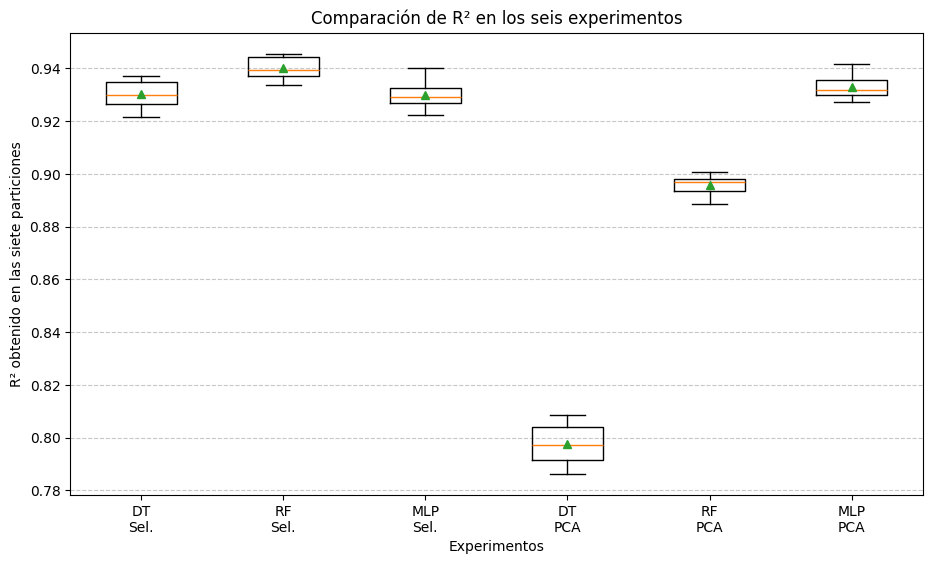

In [199]:
# =========================================================
# Boxplot de comparación de R²
# =========================================================

plt.figure(figsize=(11, 6))
plt.boxplot(datos_boxplot, labels=labels_boxplot, showmeans=True)
plt.title("Comparación de R² en los seis experimentos")
plt.xlabel("Experimentos")
plt.ylabel("R² obtenido en las siete particiones")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

El boxplot compara los valores de R² obtenidos en las siete particiones de cada experimento. La línea central representa la mediana, la caja representa el rango intercuartílico y los puntos extremos permiten identificar posibles valores atípicos.

Un experimento estable debe mostrar una caja compacta y poca diferencia entre particiones. Si un modelo presenta una caja amplia, significa que su desempeño varía más dependiendo de la partición utilizada.

In [200]:
# =========================================================
# Selección del mejor experimento general
# =========================================================

# Criterio:
# 1. Mayor R² medio
# 2. Menor MAE medio
# 3. Menor desviación estándar de R²

tabla_ranking = tabla_general_completa.sort_values(
    by=["R² medio", "MAE medio", "Desv. est. R²"],
    ascending=[False, True, True]
).reset_index(drop=True)

mejor_experimento = tabla_ranking.iloc[0]

mejor_experimento_nombre = mejor_experimento["Experimento"]
mejor_escenario = mejor_experimento["Escenario"]
mejor_modelo_nombre = mejor_experimento["Modelo"]

print("Mejor experimento general:")
print(mejor_experimento_nombre)

print("\nEscenario:")
print(mejor_escenario)

print("\nModelo:")
print(mejor_modelo_nombre)

display(tabla_ranking[
    [
        "Experimento",
        "Escenario",
        "Modelo",
        "R² medio",
        "Desv. est. R²",
        "Varianza R²",
        "MAE medio",
        "Desv. est. MAE",
        "Varianza MAE",
        "Tiempo total CV (s)"
    ]
].round(4))

Mejor experimento general:
Seleccionadas - RandomForestRegressor

Escenario:
Características seleccionadas

Modelo:
RandomForestRegressor


,Experimento,Escenario,Modelo,R² medio,Desv. est. R²,Varianza R²,MAE medio,Desv. est. MAE,Varianza MAE,Tiempo total CV (s)
0,Seleccionadas - RandomForestRegressor,Características seleccionadas,RandomForestRegressor,0.940,0.005,0.000,277.795,7.112,50.575,17.591
1,PCA - MLPRegressor,PCA,MLPRegressor,0.933,0.005,0.000,310.427,6.574,43.214,198.418
2,Seleccionadas - DecisionTreeRegressor,Características seleccionadas,DecisionTreeRegressor,0.930,0.006,0.000,303.633,7.288,53.108,1.418
3,Seleccionadas - MLPRegressor,Características seleccionadas,MLPRegressor,0.930,0.006,0.000,316.313,7.688,59.108,178.143
4,PCA - RandomForestRegressor,PCA,RandomForestRegressor,0.896,0.004,0.000,432.550,7.485,56.027,87.377
5,PCA - DecisionTreeRegressor,PCA,DecisionTreeRegressor,0.798,0.009,0.000,579.528,9.050,81.902,6.042


In [201]:
# =========================================================
# Mejor modelo por escenario
# =========================================================

mejor_por_escenario = (
    tabla_general_completa
    .sort_values(by=["Escenario", "R² medio", "MAE medio"], ascending=[True, False, True])
    .groupby("Escenario")
    .head(1)
    .reset_index(drop=True)
)

mejor_por_escenario[
    [
        "Escenario",
        "Modelo",
        "R² medio",
        "MAE medio",
        "Desv. est. R²",
        "Varianza R²"
    ]
].round(4)

,Escenario,Modelo,R² medio,MAE medio,Desv. est. R²,Varianza R²
0,Características seleccionadas,RandomForestRegressor,0.940,277.795,0.005,0.000
1,PCA,MLPRegressor,0.933,310.427,0.005,0.000


In [202]:
# =========================================================
# Comparación entre mejor modelo con seleccionadas y mejor modelo con PCA
# =========================================================

mejor_sel = mejor_por_escenario[
    mejor_por_escenario["Escenario"] == "Características seleccionadas"
].iloc[0]

mejor_pca = mejor_por_escenario[
    mejor_por_escenario["Escenario"] == "PCA"
].iloc[0]

diferencia_r2_pca = mejor_pca["R² medio"] - mejor_sel["R² medio"]
diferencia_mae_pca = mejor_pca["MAE medio"] - mejor_sel["MAE medio"]

print("Mejor modelo con características seleccionadas:")
print(mejor_sel["Modelo"])
print(f"R² medio: {mejor_sel['R² medio']:.4f}")
print(f"MAE medio: {mejor_sel['MAE medio']:.4f}")

print("\nMejor modelo con PCA:")
print(mejor_pca["Modelo"])
print(f"R² medio: {mejor_pca['R² medio']:.4f}")
print(f"MAE medio: {mejor_pca['MAE medio']:.4f}")

print("\nDiferencia PCA - Seleccionadas:")
print(f"Diferencia en R² medio: {diferencia_r2_pca:.4f}")
print(f"Diferencia en MAE medio: {diferencia_mae_pca:.4f}")

Mejor modelo con características seleccionadas:
RandomForestRegressor
R² medio: 0.9403
MAE medio: 277.7951

Mejor modelo con PCA:
MLPRegressor
R² medio: 0.9331
MAE medio: 310.4268

Diferencia PCA - Seleccionadas:
Diferencia en R² medio: -0.0072
Diferencia en MAE medio: 32.6317


In [203]:
# =========================================================
# Tabla detallada del mejor modelo
# =========================================================

tabla_mejor_particiones = tabla_particiones[
    tabla_particiones["Experimento"] == mejor_experimento_nombre
][["Partición", "R²", "MAE"]].copy()

# Filas resumen
fila_media = {
    "Partición": "Media",
    "R²": tabla_mejor_particiones["R²"].mean(),
    "MAE": tabla_mejor_particiones["MAE"].mean()
}

fila_std = {
    "Partición": "Desviación estándar",
    "R²": tabla_mejor_particiones["R²"].std(ddof=1),
    "MAE": tabla_mejor_particiones["MAE"].std(ddof=1)
}

fila_var = {
    "Partición": "Varianza",
    "R²": tabla_mejor_particiones["R²"].var(ddof=1),
    "MAE": tabla_mejor_particiones["MAE"].var(ddof=1)
}

tabla_mejor_modelo_detallada = pd.concat([
    tabla_mejor_particiones,
    pd.DataFrame([fila_media, fila_std, fila_var])
], ignore_index=True)

tabla_mejor_modelo_detallada["R²"] = tabla_mejor_modelo_detallada["R²"].round(4)
tabla_mejor_modelo_detallada["MAE"] = tabla_mejor_modelo_detallada["MAE"].round(4)

tabla_mejor_modelo_detallada

,Partición,R²,MAE
0,1,0.946,270.219
1,2,0.943,271.733
2,3,0.946,269.898
3,4,0.940,279.142
4,5,0.939,282.488
5,6,0.936,284.305
6,7,0.934,286.780
7,Media,0.940,277.795
8,Desviación estándar,0.005,7.112
9,Varianza,0.000,50.575


In [204]:
# =========================================================
# Análisis de mejor y peor partición del mejor modelo
# =========================================================

particiones_solo = tabla_mejor_particiones.copy()

mejor_particion = particiones_solo.loc[particiones_solo["R²"].idxmax()]
peor_particion = particiones_solo.loc[particiones_solo["R²"].idxmin()]

diferencia_r2 = mejor_particion["R²"] - peor_particion["R²"]
diferencia_mae = peor_particion["MAE"] - mejor_particion["MAE"]

print("Mejor partición:")
print(f"Partición: {int(mejor_particion['Partición'])}")
print(f"R²: {mejor_particion['R²']:.4f}")
print(f"MAE: {mejor_particion['MAE']:.4f}")

print("\nPeor partición:")
print(f"Partición: {int(peor_particion['Partición'])}")
print(f"R²: {peor_particion['R²']:.4f}")
print(f"MAE: {peor_particion['MAE']:.4f}")

print("\nDiferencias:")
print(f"Diferencia de R²: {diferencia_r2:.4f}")
print(f"Diferencia de MAE: {diferencia_mae:.4f}")

Mejor partición:
Partición: 1
R²: 0.9456
MAE: 270.2191

Peor partición:
Partición: 7
R²: 0.9337
MAE: 286.7800

Diferencias:
Diferencia de R²: 0.0119
Diferencia de MAE: 16.5609


In [205]:
# =========================================================
# Texto automático para el documento
# =========================================================

if diferencia_r2_pca > 0:
    efecto_pca = "mejoró"
elif diferencia_r2_pca < 0:
    efecto_pca = "empeoró"
else:
    efecto_pca = "mantuvo igual"

texto_evaluacion = f"""
El mejor modelo con características seleccionadas fue {mejor_sel['Modelo']}, con un R² medio de {mejor_sel['R² medio']:.4f} y un MAE medio de {mejor_sel['MAE medio']:.4f}.

El mejor modelo con PCA fue {mejor_pca['Modelo']}, con un R² medio de {mejor_pca['R² medio']:.4f} y un MAE medio de {mejor_pca['MAE medio']:.4f}.

Al comparar ambos escenarios, PCA {efecto_pca} el desempeño en términos de R² medio. La diferencia entre el mejor modelo con PCA y el mejor modelo con características seleccionadas fue de {diferencia_r2_pca:.4f} en R² medio y de {diferencia_mae_pca:.4f} en MAE medio.

El mejor experimento general fue {mejor_experimento_nombre}. Este experimento obtuvo un R² medio de {mejor_experimento['R² medio']:.4f}, una desviación estándar de R² de {mejor_experimento['Desv. est. R²']:.4f}, una varianza de R² de {mejor_experimento['Varianza R²']:.4f} y un MAE medio de {mejor_experimento['MAE medio']:.4f}.

La mejor partición fue la número {int(mejor_particion['Partición'])}, con un R² de {mejor_particion['R²']:.4f} y un MAE de {mejor_particion['MAE']:.4f}. La peor partición fue la número {int(peor_particion['Partición'])}, con un R² de {peor_particion['R²']:.4f} y un MAE de {peor_particion['MAE']:.4f}.

La diferencia entre la mejor y la peor partición fue de {diferencia_r2:.4f} en R². Esta diferencia permite analizar la estabilidad del modelo. Una diferencia reducida indica que el modelo mantiene un comportamiento consistente entre particiones, mientras que una diferencia alta indicaría mayor dependencia de la partición utilizada.

El modelo seleccionado no fue elegido por obtener un resultado alto en una sola partición, sino por su desempeño promedio, su estabilidad, su error absoluto medio y su viabilidad para ser desplegado posteriormente en una aplicación web.
"""

print(texto_evaluacion)


El mejor modelo con características seleccionadas fue RandomForestRegressor, con un R² medio de 0.9403 y un MAE medio de 277.7951.

El mejor modelo con PCA fue MLPRegressor, con un R² medio de 0.9331 y un MAE medio de 310.4268.

Al comparar ambos escenarios, PCA empeoró el desempeño en términos de R² medio. La diferencia entre el mejor modelo con PCA y el mejor modelo con características seleccionadas fue de -0.0072 en R² medio y de 32.6317 en MAE medio.

El mejor experimento general fue Seleccionadas - RandomForestRegressor. Este experimento obtuvo un R² medio de 0.9403, una desviación estándar de R² de 0.0047, una varianza de R² de 0.0000 y un MAE medio de 277.7951.

La mejor partición fue la número 1, con un R² de 0.9456 y un MAE de 270.2191. La peor partición fue la número 7, con un R² de 0.9337 y un MAE de 286.7800.

La diferencia entre la mejor y la peor partición fue de 0.0119 en R². Esta diferencia permite analizar la estabilidad del modelo. Una diferencia reducida indica que 

La evaluación mediante validación cruzada permitió comparar los seis experimentos bajo condiciones equivalentes. El mejor modelo se seleccionó considerando el R² medio, MAE medio, desviación estándar, varianza, estabilidad entre particiones, tiempo de entrenamiento y viabilidad para el despliegue.

El análisis detallado de las siete particiones del mejor modelo permite comprobar si el resultado promedio es representativo y si existen particiones atípicas.

## 3.7 Evaluación final del mejor modelo

Después de seleccionar el mejor experimento general, se realiza una evaluación adicional únicamente para ese modelo.

Se utiliza `train_test_split` con:

- 80% para entrenamiento.
- 20% para prueba.
- Semilla fija.

El pipeline conserva la misma configuración utilizada en la validación cruzada.

In [206]:
# =========================================================
# 3.7 Evaluación final del mejor modelo
# Selección del mejor pipeline y datos correspondientes
# =========================================================

# Se recupera la información del mejor experimento identificado en 3.6
info_mejor = experimentos[mejor_experimento_nombre]

X_mejor = info_mejor["X"]
pipeline_mejor = clone(info_mejor["Pipeline"])

print("Mejor experimento seleccionado:")
print(mejor_experimento_nombre)

print("\nEscenario:")
print(info_mejor["Escenario"])

print("\nModelo:")
print(info_mejor["Modelo"])

print("\nDimensiones de X utilizado por el mejor modelo:")
print(X_mejor.shape)

Mejor experimento seleccionado:
Seleccionadas - RandomForestRegressor

Escenario:
Características seleccionadas

Modelo:
RandomForestRegressor

Dimensiones de X utilizado por el mejor modelo:
(48187, 6)


In [207]:
# =========================================================
# División de entrenamiento y prueba
# =========================================================

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_mejor,
    y,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)

print("Registros de entrenamiento:")
print(X_train_final.shape[0])

print("\nRegistros de prueba:")
print(X_test_final.shape[0])

print("\nPorcentaje de entrenamiento:")
print(round(X_train_final.shape[0] / X_mejor.shape[0] * 100, 2), "%")

print("\nPorcentaje de prueba:")
print(round(X_test_final.shape[0] / X_mejor.shape[0] * 100, 2), "%")

Registros de entrenamiento:
38549

Registros de prueba:
9638

Porcentaje de entrenamiento:
80.0 %

Porcentaje de prueba:
20.0 %


La división de datos se realizó con 80% para entrenamiento y 20% para prueba. El conjunto de prueba no se utiliza durante el ajuste del pipeline, por lo que permite evaluar el comportamiento del modelo en datos no vistos.

In [208]:
# =========================================================
# Entrenamiento del mejor modelo y predicción
# =========================================================

inicio_final = time.perf_counter()

pipeline_mejor.fit(X_train_final, y_train_final)

fin_final = time.perf_counter()
tiempo_entrenamiento_final = fin_final - inicio_final

y_pred_final = pipeline_mejor.predict(X_test_final)

r2_final = r2_score(y_test_final, y_pred_final)
mae_final = mean_absolute_error(y_test_final, y_pred_final)

print("Resultados de evaluación final con train_test_split")
print("---------------------------------------------------")
print(f"Mejor experimento: {mejor_experimento_nombre}")
print(f"R² en prueba: {r2_final:.4f}")
print(f"MAE en prueba: {mae_final:.4f}")
print(f"Tiempo de entrenamiento final: {tiempo_entrenamiento_final:.3f} segundos")

Resultados de evaluación final con train_test_split
---------------------------------------------------
Mejor experimento: Seleccionadas - RandomForestRegressor
R² en prueba: 0.9431
MAE en prueba: 274.4385
Tiempo de entrenamiento final: 2.416 segundos


In [209]:
# =========================================================
# Tabla de valores reales, predichos y error
# =========================================================

tabla_predicciones = pd.DataFrame({
    "Valor real": y_test_final.values,
    "Valor predicho": y_pred_final,
    "Residuo": y_test_final.values - y_pred_final,
    "Error absoluto": np.abs(y_test_final.values - y_pred_final)
})

tabla_predicciones.head(20)

,Valor real,Valor predicho,Residuo,Error absoluto
0,4924,4707.023,216.977,216.977
1,3800,4239.921,-439.921,439.921
2,5124,5118.413,5.587,5.587
3,4986,5318.205,-332.205,332.205
4,4735,4246.416,488.584,488.584
5,3055,2412.537,642.463,642.463
6,1724,1778.947,-54.947,54.947
7,4028,2839.209,1188.791,1188.791
8,3397,3414.039,-17.039,17.039
9,5597,5326.030,270.970,270.970


In [210]:
# =========================================================
# Resumen de errores
# =========================================================

residuos = y_test_final.values - y_pred_final
errores_absolutos = np.abs(residuos)

resumen_errores_final = pd.DataFrame({
    "Métrica": [
        "R² prueba",
        "MAE prueba",
        "Media de residuos",
        "Mediana de residuos",
        "Desviación estándar de residuos",
        "Residuo mínimo",
        "Residuo máximo",
        "Percentil 5 del residuo",
        "Percentil 95 del residuo",
        "Error absoluto mediano",
        "Error absoluto máximo"
    ],
    "Valor": [
        r2_final,
        mae_final,
        np.mean(residuos),
        np.median(residuos),
        np.std(residuos, ddof=1),
        np.min(residuos),
        np.max(residuos),
        np.percentile(residuos, 5),
        np.percentile(residuos, 95),
        np.median(errores_absolutos),
        np.max(errores_absolutos)
    ]
})

resumen_errores_final["Valor"] = resumen_errores_final["Valor"].round(4)
resumen_errores_final

,Métrica,Valor
0,R² prueba,0.943
1,MAE prueba,274.438
2,Media de residuos,14.191
3,Mediana de residuos,9.820
4,Desviación estándar de residuos,476.959
5,Residuo mínimo,-5380.348
6,Residuo máximo,3131.356
7,Percentil 5 del residuo,-601.311
8,Percentil 95 del residuo,662.415
9,Error absoluto mediano,154.696


### Gráfica de valores reales contra valores predichos

Esta gráfica compara los valores reales de `traffic_volume` contra las predicciones del modelo. La línea diagonal representa una predicción ideal.

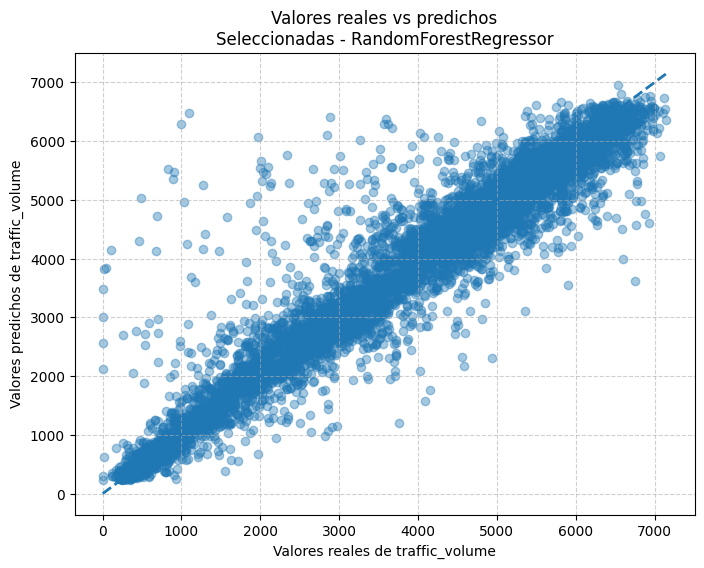

In [211]:
# =========================================================
# Gráfica de valores reales contra valores predichos
# =========================================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test_final, y_pred_final, alpha=0.4)

min_val = min(y_test_final.min(), y_pred_final.min())
max_val = max(y_test_final.max(), y_pred_final.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=2)

plt.title(f"Valores reales vs predichos\n{mejor_experimento_nombre}")
plt.xlabel("Valores reales de traffic_volume")
plt.ylabel("Valores predichos de traffic_volume")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [212]:
# =========================================================
# Análisis de sobreestimación y subestimación
# =========================================================

# Residuo = real - predicho
# Residuo positivo: el modelo predijo menos de lo real, subestimó.
# Residuo negativo: el modelo predijo más de lo real, sobreestimó.

subestimaciones = np.sum(residuos > 0)
sobreestimaciones = np.sum(residuos < 0)
predicciones_exactas = np.sum(residuos == 0)

total_predicciones = len(residuos)

tabla_sesgo = pd.DataFrame({
    "Tipo de caso": [
        "Subestimación",
        "Sobreestimación",
        "Predicción exacta"
    ],
    "Cantidad": [
        subestimaciones,
        sobreestimaciones,
        predicciones_exactas
    ],
    "Porcentaje": [
        subestimaciones / total_predicciones * 100,
        sobreestimaciones / total_predicciones * 100,
        predicciones_exactas / total_predicciones * 100
    ]
})

tabla_sesgo["Porcentaje"] = tabla_sesgo["Porcentaje"].round(2)

tabla_sesgo

,Tipo de caso,Cantidad,Porcentaje
0,Subestimación,5087,52.780
1,Sobreestimación,4551,47.220
2,Predicción exacta,0,0.000


In [213]:
# =========================================================
# Error absoluto por rangos de tráfico real
# =========================================================

tabla_predicciones["Rango tráfico real"] = pd.qcut(
    tabla_predicciones["Valor real"],
    q=4,
    duplicates="drop"
)

error_por_rango_real = (
    tabla_predicciones
    .groupby("Rango tráfico real", observed=True)
    .agg(
        registros=("Error absoluto", "count"),
        valor_real_promedio=("Valor real", "mean"),
        prediccion_promedio=("Valor predicho", "mean"),
        error_absoluto_promedio=("Error absoluto", "mean"),
        residuo_promedio=("Residuo", "mean")
    )
    .reset_index()
)

error_por_rango_real.round(4)

,Rango tráfico real,registros,valor_real_promedio,prediccion_promedio,error_absoluto_promedio,residuo_promedio
0,"(0.999, 1191.0]",2411,579.338,646.031,119.307,-66.692
1,"(1191.0, 3460.0]",2408,2462.732,2575.537,331.027,-112.805
2,"(3460.0, 4957.0]",2411,4355.334,4328.279,313.077,27.055
3,"(4957.0, 7150.0]",2408,5721.331,5512.041,334.488,209.290


La gráfica de valores reales contra predichos permite observar si las predicciones se aproximan a la línea ideal. Los puntos cercanos a la línea indican predicciones más precisas, mientras que puntos alejados representan errores mayores.

Los puntos por encima de la línea indican subestimaciones y los puntos por debajo indican sobreestimaciones. La tabla por rangos permite observar si el error cambia dependiendo del nivel real de tráfico.

### Gráfica de residuos

Los residuos se calculan como:

**Residuo = valor real − valor predicho**

La gráfica muestra los residuos en función de los valores predichos. La línea horizontal en cero representa ausencia de error.

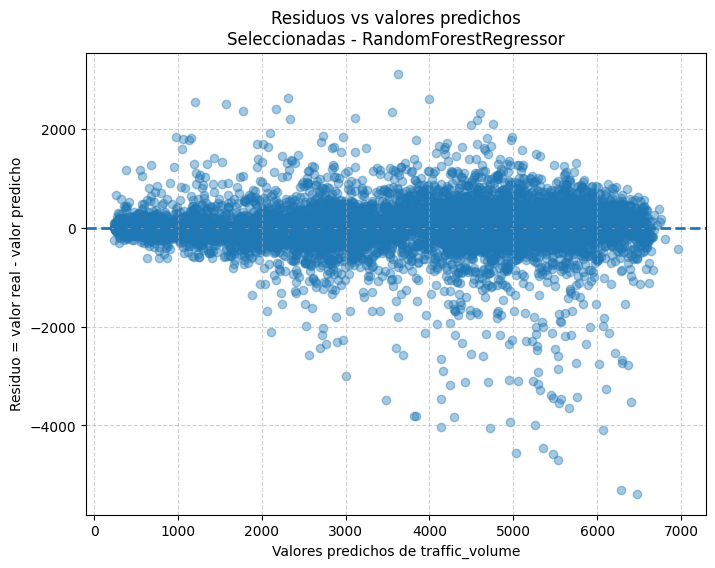

In [214]:
# =========================================================
# Gráfica de residuos contra valores predichos
# =========================================================

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_final, residuos, alpha=0.4)
plt.axhline(y=0, linestyle="--", linewidth=2)

plt.title(f"Residuos vs valores predichos\n{mejor_experimento_nombre}")
plt.xlabel("Valores predichos de traffic_volume")
plt.ylabel("Residuo = valor real - valor predicho")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

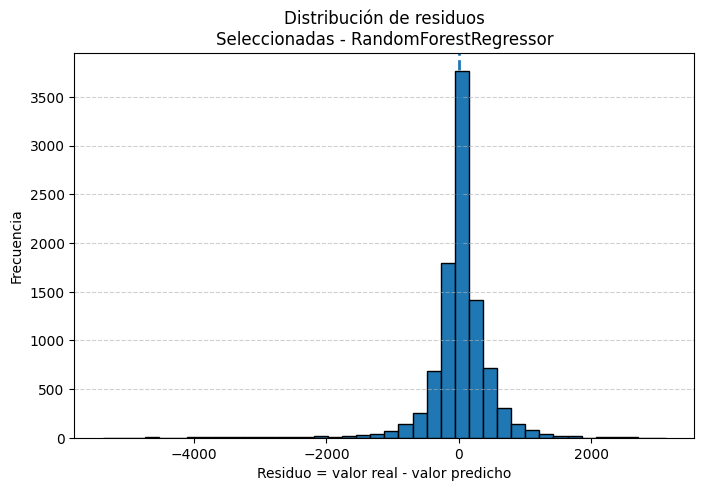

In [215]:
# =========================================================
# Histograma de residuos
# =========================================================

plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=40, edgecolor="black")
plt.axvline(x=0, linestyle="--", linewidth=2)

plt.title(f"Distribución de residuos\n{mejor_experimento_nombre}")
plt.xlabel("Residuo = valor real - valor predicho")
plt.ylabel("Frecuencia")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [216]:
# =========================================================
# Análisis aproximado de heterocedasticidad
# =========================================================

# Se analiza si el tamaño del error absoluto aumenta
# conforme cambian los valores predichos.

tabla_predicciones["Valor predicho"] = y_pred_final
tabla_predicciones["Rango predicción"] = pd.qcut(
    tabla_predicciones["Valor predicho"],
    q=4,
    duplicates="drop"
)

error_por_rango_predicho = (
    tabla_predicciones
    .groupby("Rango predicción", observed=True)
    .agg(
        registros=("Error absoluto", "count"),
        prediccion_promedio=("Valor predicho", "mean"),
        error_absoluto_promedio=("Error absoluto", "mean"),
        desviacion_residuos=("Residuo", "std"),
        residuo_promedio=("Residuo", "mean")
    )
    .reset_index()
)

correlacion_error_prediccion = np.corrcoef(
    tabla_predicciones["Valor predicho"],
    tabla_predicciones["Error absoluto"]
)[0, 1]

print(f"Correlación entre valor predicho y error absoluto: {correlacion_error_prediccion:.4f}")

error_por_rango_predicho.round(4)

Correlación entre valor predicho y error absoluto: 0.2598


,Rango predicción,registros,prediccion_promedio,error_absoluto_promedio,desviacion_residuos,residuo_promedio
0,"(237.958, 1251.393]",2410,598.851,84.419,171.816,7.023
1,"(1251.393, 3488.006]",2409,2523.036,296.127,451.840,-4.585
2,"(3488.006, 4876.19]",2409,4344.274,353.554,547.369,58.119
3,"(4876.19, 6961.956]",2410,5593.928,363.696,611.812,-3.783


La gráfica de residuos permite identificar si el modelo presenta sesgo o patrones de error. Si los residuos se distribuyen de forma aleatoria alrededor de cero, el modelo no muestra un sesgo fuerte. Si los residuos forman una curva, abanico o patrón claro, podría existir una relación no capturada por el modelo.

La tabla por rangos de predicción permite revisar si el error absoluto aumenta en ciertos niveles de tráfico. Si el error crece conforme aumentan las predicciones, podría existir heterocedasticidad.

In [217]:
# =========================================================
# Texto automático para copiar al documento Word
# =========================================================

residuo_medio = np.mean(residuos)
residuo_mediano = np.median(residuos)
residuo_std = np.std(residuos, ddof=1)
residuo_min = np.min(residuos)
residuo_max = np.max(residuos)

error_abs_mediano = np.median(errores_absolutos)
error_abs_max = np.max(errores_absolutos)

if residuo_medio > 0:
    interpretacion_sesgo = "ligera tendencia a subestimar el tráfico"
elif residuo_medio < 0:
    interpretacion_sesgo = "ligera tendencia a sobreestimar el tráfico"
else:
    interpretacion_sesgo = "sin tendencia promedio clara hacia la sobreestimación o subestimación"

if abs(correlacion_error_prediccion) < 0.20:
    interpretacion_hetero = "no se observa una relación fuerte entre el tamaño del error y el valor predicho"
elif correlacion_error_prediccion > 0:
    interpretacion_hetero = "el error tiende a aumentar conforme crecen los valores predichos"
else:
    interpretacion_hetero = "el error tiende a disminuir conforme crecen los valores predichos"

texto_evaluacion_final = f"""
La evaluación final se realizó únicamente sobre el mejor experimento seleccionado: {mejor_experimento_nombre}. Para esta prueba se utilizó una división 80/20 mediante train_test_split, con semilla fija, conservando el mismo pipeline utilizado durante la validación cruzada.

En el conjunto de prueba, el modelo obtuvo un R² de {r2_final:.4f} y un MAE de {mae_final:.4f}. Esto significa que el modelo mantiene un desempeño consistente en datos no utilizados durante el entrenamiento. El MAE indica que, en promedio, las predicciones se alejan aproximadamente {mae_final:.2f} vehículos por hora del valor real.

En la gráfica de valores reales contra predichos, los puntos cercanos a la línea diagonal representan predicciones más precisas. Los puntos ubicados por encima de la línea corresponden a subestimaciones, mientras que los puntos ubicados por debajo corresponden a sobreestimaciones. En esta evaluación se observaron {subestimaciones} casos de subestimación y {sobreestimaciones} casos de sobreestimación.

Los residuos se calcularon como valor real menos valor predicho. La media de los residuos fue {residuo_medio:.4f}, lo cual indica {interpretacion_sesgo}. La desviación estándar de los residuos fue {residuo_std:.4f}, con un residuo mínimo de {residuo_min:.4f} y un residuo máximo de {residuo_max:.4f}. Esto muestra que, aunque la mayoría de los errores se concentran alrededor de cero, existen algunos casos con errores más grandes.

La correlación entre el valor predicho y el error absoluto fue {correlacion_error_prediccion:.4f}; por lo tanto, {interpretacion_hetero}. Esto ayuda a evaluar la posible presencia de heterocedasticidad. En general, la gráfica de residuos permite observar si los errores se distribuyen de manera relativamente aleatoria o si existen patrones que indiquen limitaciones del modelo.

Los errores extremos pueden estar relacionados con factores que no están presentes en el dataset, como accidentes, obras, eventos especiales, cierres viales o cambios repentinos en el comportamiento del tráfico. Por ello, aunque el modelo presenta un desempeño adecuado, sus predicciones deben interpretarse como apoyo a la toma de decisiones y no como valores exactos garantizados.
"""

print(texto_evaluacion_final)


La evaluación final se realizó únicamente sobre el mejor experimento seleccionado: Seleccionadas - RandomForestRegressor. Para esta prueba se utilizó una división 80/20 mediante train_test_split, con semilla fija, conservando el mismo pipeline utilizado durante la validación cruzada.

En el conjunto de prueba, el modelo obtuvo un R² de 0.9431 y un MAE de 274.4385. Esto significa que el modelo mantiene un desempeño consistente en datos no utilizados durante el entrenamiento. El MAE indica que, en promedio, las predicciones se alejan aproximadamente 274.44 vehículos por hora del valor real.

En la gráfica de valores reales contra predichos, los puntos cercanos a la línea diagonal representan predicciones más precisas. Los puntos ubicados por encima de la línea corresponden a subestimaciones, mientras que los puntos ubicados por debajo corresponden a sobreestimaciones. En esta evaluación se observaron 5087 casos de subestimación y 4551 casos de sobreestimación.

Los residuos se calcularo

## 3.8 Despliegue del modelo

En esta etapa se prepara el mejor modelo seleccionado para su despliegue mediante Flask y Render.

El mejor experimento fue **Seleccionadas - RandomForestRegressor**, por lo que se entrenará un pipeline final con todas las observaciones disponibles y se guardará mediante `joblib`.

El pipeline final incluye:

- Imputación.
- Codificación de variables categóricas.
- Escalado.
- Características seleccionadas.
- Modelo RandomForestRegressor.

In [218]:
# =========================================================
# 3.8 Despliegue del modelo
# Importar librerías para almacenamiento
# =========================================================

import os
import json
import joblib
from pathlib import Path

In [219]:
# =========================================================
# Confirmar mejor experimento seleccionado
# =========================================================

print("Mejor experimento seleccionado:")
print(mejor_experimento_nombre)

print("\nEscenario:")
print(mejor_escenario)

print("\nModelo:")
print(mejor_modelo_nombre)

print("\nCaracterísticas utilizadas:")
print(selected_features)

Mejor experimento seleccionado:
Seleccionadas - RandomForestRegressor

Escenario:
Características seleccionadas

Modelo:
RandomForestRegressor

Características utilizadas:
['hour', 'day_of_week', 'is_weekend', 'temp', 'clouds_all', 'weather_main']


In [220]:
# =========================================================
# Entrenamiento final del mejor pipeline con todos los datos
# =========================================================

# Como el mejor experimento fue con características seleccionadas,
# se utiliza X_selected y el pipeline correspondiente.

pipeline_final = clone(experimentos[mejor_experimento_nombre]["Pipeline"])

inicio_entrenamiento_final = time.perf_counter()

pipeline_final.fit(X_selected, y)

fin_entrenamiento_final = time.perf_counter()

tiempo_entrenamiento_pipeline_final = fin_entrenamiento_final - inicio_entrenamiento_final

print("Pipeline final entrenado correctamente.")
print(f"Tiempo de entrenamiento final: {tiempo_entrenamiento_pipeline_final:.3f} segundos")

Pipeline final entrenado correctamente.
Tiempo de entrenamiento final: 2.971 segundos


El pipeline final se entrenó nuevamente con todos los registros disponibles después de haber terminado la evaluación y selección del mejor modelo. Esto permite utilizar la mayor cantidad de información posible para el modelo que será desplegado.

In [221]:
# =========================================================
# Crear estructura de carpetas para Render
# =========================================================

render_dir = Path("render_app")
templates_dir = render_dir / "templates"
static_dir = render_dir / "static"

templates_dir.mkdir(parents=True, exist_ok=True)
static_dir.mkdir(parents=True, exist_ok=True)

print("Carpetas creadas:")
print(render_dir)
print(templates_dir)
print(static_dir)

Carpetas creadas:
render_app
render_app\templates
render_app\static


In [222]:
# =========================================================
# Guardar pipeline final
# =========================================================

modelo_path = render_dir / "modelo_pipeline.joblib"

joblib.dump(pipeline_final, modelo_path, compress=3)

print(f"Pipeline guardado correctamente en: {modelo_path}")
print(f"Tamaño del archivo: {modelo_path.stat().st_size / 1024 / 1024:.2f} MB")

Pipeline guardado correctamente en: render_app\modelo_pipeline.joblib
Tamaño del archivo: 20.96 MB


In [223]:
# =========================================================
# Guardar información del modelo
# =========================================================

modelo_info = {
    "nombre_proyecto": "Predicción de volumen de tráfico vehicular",
    "dataset": "Metro Interstate Traffic Volume",
    "variable_objetivo": "traffic_volume",
    "unidad_prediccion": "vehículos por hora",
    "mejor_experimento": mejor_experimento_nombre,
    "escenario": mejor_escenario,
    "modelo": mejor_modelo_nombre,
    "features": selected_features,
    "r2_prueba": round(float(r2_final), 4),
    "mae_prueba": round(float(mae_final), 4)
}

info_path = render_dir / "modelo_info.json"

with open(info_path, "w", encoding="utf-8") as f:
    json.dump(modelo_info, f, ensure_ascii=False, indent=4)

print("Información del modelo guardada:")
display(modelo_info)

Información del modelo guardada:


{'nombre_proyecto': 'Predicción de volumen de tráfico vehicular',
 'dataset': 'Metro Interstate Traffic Volume',
 'variable_objetivo': 'traffic_volume',
 'unidad_prediccion': 'vehículos por hora',
 'mejor_experimento': 'Seleccionadas - RandomForestRegressor',
 'escenario': 'Características seleccionadas',
 'modelo': 'RandomForestRegressor',
 'features': ['hour',
  'day_of_week',
  'is_weekend',
  'temp',
  'clouds_all',
  'weather_main'],
 'r2_prueba': 0.9431,
 'mae_prueba': 274.4385}

In [224]:
# =========================================================
# Prueba de carga del pipeline guardado
# =========================================================

pipeline_cargado = joblib.load(modelo_path)

print("Pipeline cargado correctamente.")
print(pipeline_cargado)

Pipeline cargado correctamente.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hour', 'day_of_week',
                                                   'is_weekend', 'temp',
                                                   'clouds_all']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot'

In [225]:
# =========================================================
# Prueba de predicción con datos originales interpretables
# =========================================================

ejemplo_prediccion = pd.DataFrame([{
    "hour": 8,
    "day_of_week": 0,
    "is_weekend": 0,
    "temp": 285.15,
    "clouds_all": 40,
    "weather_main": "Clouds"
}])

prediccion_ejemplo = pipeline_cargado.predict(ejemplo_prediccion)[0]

print("Datos de ejemplo:")
display(ejemplo_prediccion)

print(f"Predicción estimada de tráfico: {prediccion_ejemplo:.0f} vehículos por hora")

Datos de ejemplo:


,hour,day_of_week,is_weekend,temp,clouds_all,weather_main
0,8,0,0,285.150,40,Clouds


Predicción estimada de tráfico: 5278 vehículos por hora


La prueba anterior confirma que el pipeline guardado puede cargarse correctamente y generar una predicción usando valores originales e interpretables. El usuario no necesita ingresar columnas codificadas ni valores escalados, ya que el pipeline realiza internamente el preprocesamiento.

In [226]:
# =========================================================
# Crear archivo app.py para Flask
# =========================================================

app_py = r'''
from flask import Flask, render_template, request
import pandas as pd
import joblib
import json
from pathlib import Path

app = Flask(__name__)

BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR / "modelo_pipeline.joblib"
INFO_PATH = BASE_DIR / "modelo_info.json"

# Cargar modelo
modelo = joblib.load(MODEL_PATH)

# Cargar información del modelo
with open(INFO_PATH, "r", encoding="utf-8") as f:
    modelo_info = json.load(f)

WEATHER_OPTIONS = [
    "Clear",
    "Clouds",
    "Mist",
    "Rain",
    "Snow",
    "Drizzle",
    "Haze",
    "Thunderstorm",
    "Fog",
    "Smoke",
    "Squall"
]

def validar_entrada(hour, day_of_week, is_weekend, temp, clouds_all, weather_main):
    errores = []

    if hour < 0 or hour > 23:
        errores.append("La hora debe estar entre 0 y 23.")

    if day_of_week < 0 or day_of_week > 6:
        errores.append("El día de la semana debe estar entre 0 y 6.")

    if is_weekend not in [0, 1]:
        errores.append("El campo fin de semana debe ser 0 o 1.")

    if temp < 230 or temp > 330:
        errores.append("La temperatura debe estar en un rango razonable entre 230 y 330 Kelvin.")

    if clouds_all < 0 or clouds_all > 100:
        errores.append("La nubosidad debe estar entre 0 y 100 por ciento.")

    if weather_main not in WEATHER_OPTIONS:
        errores.append("La condición climática seleccionada no es válida.")

    return errores


@app.route("/", methods=["GET", "POST"])
def index():
    resultado = None
    errores = []
    valores = {
        "hour": "8",
        "day_of_week": "0",
        "is_weekend": "0",
        "temp": "285.15",
        "clouds_all": "40",
        "weather_main": "Clouds"
    }

    if request.method == "POST":
        valores = {
            "hour": request.form.get("hour", ""),
            "day_of_week": request.form.get("day_of_week", ""),
            "is_weekend": request.form.get("is_weekend", ""),
            "temp": request.form.get("temp", ""),
            "clouds_all": request.form.get("clouds_all", ""),
            "weather_main": request.form.get("weather_main", "")
        }

        try:
            hour = int(valores["hour"])
            day_of_week = int(valores["day_of_week"])
            is_weekend = int(valores["is_weekend"])
            temp = float(valores["temp"])
            clouds_all = float(valores["clouds_all"])
            weather_main = valores["weather_main"]

            errores = validar_entrada(
                hour,
                day_of_week,
                is_weekend,
                temp,
                clouds_all,
                weather_main
            )

            if not errores:
                entrada = pd.DataFrame([{
                    "hour": hour,
                    "day_of_week": day_of_week,
                    "is_weekend": is_weekend,
                    "temp": temp,
                    "clouds_all": clouds_all,
                    "weather_main": weather_main
                }])

                prediccion = modelo.predict(entrada)[0]

                # Evitar mostrar predicciones negativas si llegaran a ocurrir
                prediccion = max(0, prediccion)

                resultado = round(prediccion, 0)

        except ValueError:
            errores.append("Verifica que los campos numéricos tengan valores válidos.")

        except Exception as e:
            errores.append(f"Ocurrió un error al generar la predicción: {str(e)}")

    return render_template(
        "index.html",
        resultado=resultado,
        errores=errores,
        valores=valores,
        weather_options=WEATHER_OPTIONS,
        modelo_info=modelo_info
    )


if __name__ == "__main__":
    app.run(debug=True)
'''

with open(render_dir / "app.py", "w", encoding="utf-8") as f:
    f.write(app_py)

print("Archivo app.py creado correctamente.")

Archivo app.py creado correctamente.


In [227]:
# =========================================================
# Crear archivo index.html
# =========================================================

index_html = r'''
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <title>Predicción de Tráfico Vehicular</title>
    <link rel="stylesheet" href="{{ url_for('static', filename='styles.css') }}">
</head>

<body>
    <main class="container">
        <section class="card">
            <h1>Predicción de volumen de tráfico vehicular</h1>

            <p class="intro">
                Esta aplicación utiliza un modelo de aprendizaje automático para estimar
                el volumen horario de tráfico vehicular en la carretera I-94.
            </p>

            <div class="model-info">
                <p><strong>Modelo:</strong> {{ modelo_info.modelo }}</p>
                <p><strong>Escenario:</strong> {{ modelo_info.escenario }}</p>
                <p><strong>Variable objetivo:</strong> {{ modelo_info.variable_objetivo }}</p>
                <p><strong>Unidad del resultado:</strong> vehículos por hora</p>
            </div>

            {% if errores %}
                <div class="error-box">
                    <strong>Revisa los siguientes puntos:</strong>
                    <ul>
                        {% for error in errores %}
                            <li>{{ error }}</li>
                        {% endfor %}
                    </ul>
                </div>
            {% endif %}

            <form method="POST" class="form-grid">
                <div class="form-group">
                    <label for="hour">Hora del día</label>
                    <input type="number" id="hour" name="hour" min="0" max="23" value="{{ valores.hour }}" required>
                    <small>Valor entre 0 y 23.</small>
                </div>

                <div class="form-group">
                    <label for="day_of_week">Día de la semana</label>
                    <select id="day_of_week" name="day_of_week" required>
                        <option value="0" {% if valores.day_of_week == "0" %}selected{% endif %}>Lunes</option>
                        <option value="1" {% if valores.day_of_week == "1" %}selected{% endif %}>Martes</option>
                        <option value="2" {% if valores.day_of_week == "2" %}selected{% endif %}>Miércoles</option>
                        <option value="3" {% if valores.day_of_week == "3" %}selected{% endif %}>Jueves</option>
                        <option value="4" {% if valores.day_of_week == "4" %}selected{% endif %}>Viernes</option>
                        <option value="5" {% if valores.day_of_week == "5" %}selected{% endif %}>Sábado</option>
                        <option value="6" {% if valores.day_of_week == "6" %}selected{% endif %}>Domingo</option>
                    </select>
                    <small>0=Lunes, 6=Domingo.</small>
                </div>

                <div class="form-group">
                    <label for="is_weekend">¿Es fin de semana?</label>
                    <select id="is_weekend" name="is_weekend" required>
                        <option value="0" {% if valores.is_weekend == "0" %}selected{% endif %}>No</option>
                        <option value="1" {% if valores.is_weekend == "1" %}selected{% endif %}>Sí</option>
                    </select>
                    <small>Sábado o domingo.</small>
                </div>

                <div class="form-group">
                    <label for="temp">Temperatura</label>
                    <input type="number" step="0.01" id="temp" name="temp" value="{{ valores.temp }}" required>
                    <small>Temperatura en Kelvin. Ejemplo: 285.15 K.</small>
                </div>

                <div class="form-group">
                    <label for="clouds_all">Nubosidad</label>
                    <input type="number" step="1" id="clouds_all" name="clouds_all" min="0" max="100" value="{{ valores.clouds_all }}" required>
                    <small>Porcentaje de nubosidad entre 0 y 100.</small>
                </div>

                <div class="form-group">
                    <label for="weather_main">Condición climática</label>
                    <select id="weather_main" name="weather_main" required>
                        {% for option in weather_options %}
                            <option value="{{ option }}" {% if valores.weather_main == option %}selected{% endif %}>
                                {{ option }}
                            </option>
                        {% endfor %}
                    </select>
                    <small>Condición climática general.</small>
                </div>

                <button type="submit" class="btn">Realizar predicción</button>
            </form>

            {% if resultado is not none %}
                <div class="result-box">
                    <h2>Resultado estimado</h2>
                    <p class="result-number">{{ resultado }}</p>
                    <p>vehículos por hora</p>
                </div>
            {% endif %}
        </section>
    </main>
</body>
</html>
'''

with open(templates_dir / "index.html", "w", encoding="utf-8") as f:
    f.write(index_html)

print("Archivo templates/index.html creado correctamente.")

Archivo templates/index.html creado correctamente.


In [228]:
# =========================================================
# Crear archivo styles.css
# =========================================================

styles_css = r'''
* {
    box-sizing: border-box;
}

body {
    margin: 0;
    font-family: Arial, sans-serif;
    background: linear-gradient(135deg, #1f2937, #111827);
    color: #111827;
}

.container {
    min-height: 100vh;
    display: flex;
    align-items: center;
    justify-content: center;
    padding: 30px;
}

.card {
    width: 100%;
    max-width: 920px;
    background: #ffffff;
    border-radius: 18px;
    padding: 32px;
    box-shadow: 0 20px 60px rgba(0, 0, 0, 0.25);
}

h1 {
    margin-top: 0;
    color: #111827;
    text-align: center;
}

.intro {
    text-align: center;
    color: #4b5563;
    line-height: 1.6;
}

.model-info {
    background: #f3f4f6;
    border-left: 5px solid #2563eb;
    padding: 14px 18px;
    margin: 24px 0;
    border-radius: 10px;
}

.model-info p {
    margin: 6px 0;
}

.form-grid {
    display: grid;
    grid-template-columns: repeat(2, 1fr);
    gap: 18px;
}

.form-group {
    display: flex;
    flex-direction: column;
}

label {
    font-weight: bold;
    margin-bottom: 6px;
}

input,
select {
    padding: 12px;
    border: 1px solid #d1d5db;
    border-radius: 10px;
    font-size: 15px;
}

small {
    margin-top: 5px;
    color: #6b7280;
}

.btn {
    grid-column: 1 / -1;
    padding: 14px;
    background: #2563eb;
    color: #ffffff;
    border: none;
    border-radius: 12px;
    font-size: 17px;
    cursor: pointer;
    font-weight: bold;
}

.btn:hover {
    background: #1d4ed8;
}

.result-box {
    margin-top: 24px;
    padding: 22px;
    text-align: center;
    border-radius: 14px;
    background: #ecfdf5;
    border: 1px solid #10b981;
}

.result-box h2 {
    margin-top: 0;
    color: #065f46;
}

.result-number {
    font-size: 46px;
    font-weight: bold;
    color: #047857;
    margin: 10px 0;
}

.error-box {
    background: #fef2f2;
    border: 1px solid #ef4444;
    color: #991b1b;
    border-radius: 12px;
    padding: 14px 18px;
    margin: 18px 0;
}

@media (max-width: 720px) {
    .form-grid {
        grid-template-columns: 1fr;
    }

    .card {
        padding: 22px;
    }
}
'''

with open(static_dir / "styles.css", "w", encoding="utf-8") as f:
    f.write(styles_css)

print("Archivo static/styles.css creado correctamente.")

Archivo static/styles.css creado correctamente.


In [229]:
# =========================================================
# Crear archivo requirements.txt
# =========================================================

requirements_txt = """Flask
gunicorn
pandas
numpy
scikit-learn
joblib
"""

with open(render_dir / "requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_txt)

print("Archivo requirements.txt creado correctamente.")

Archivo requirements.txt creado correctamente.


In [230]:
# =========================================================
# Crear archivo URL_Render.txt
# =========================================================

url_render_txt = """URL pública de Render:

PENDIENTE: pegar aquí la URL cuando la aplicación sea publicada.

Ejemplo:
https://metro-traffic-volume-regression.onrender.com
"""

with open("URL_Render.txt", "w", encoding="utf-8") as f:
    f.write(url_render_txt)

print("Archivo URL_Render.txt creado correctamente.")

Archivo URL_Render.txt creado correctamente.


In [231]:
# =========================================================
# Mostrar estructura de archivos para Render
# =========================================================

for root, dirs, files in os.walk(render_dir):
    nivel = root.replace(str(render_dir), "").count(os.sep)
    indent = " " * 4 * nivel
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (nivel + 1)
    for file in files:
        print(f"{subindent}{file}")

render_app/
    app.py
    modelo_info.json
    modelo_pipeline.joblib
    requirements.txt
    static/
        styles.css
    templates/
        index.html
